# TalkEx v5: Classificação de Intenções por Janela de Contexto — Cascata Corrigida

**TCC — Centro de Competências Embrapii em Tecnologias Imersivas (AKCIT)**

Cauê C. Leão &bull; Paulo H. V. Nascimento &bull; Suele S. F. Sousa

---

### Pergunta de pesquisa

> *Como a classificação por similaridade semântica no nível de janelas de contexto configuráveis,
> combinando recuperação lexical (BM25), embeddings multilíngues e regras determinísticas,
> pode classificar intenções em conversas de atendimento ao cliente em português brasileiro
> — com taxonomia dinâmica definida pela equipe de negócio?*

### Hipóteses

| | Hipótese | Métrica principal |
|:---:|:---|:---|
| **H1** | Recuperação híbrida (BM25 + embeddings) supera paradigmas isolados | Macro-F1 |
| **H2** | Embedding KNN supera BM25 KNN na classificação por janela | Macro-F1 |
| **H3** | Regras determinísticas complementam classificação por similaridade | Macro-F1 |
| **H4** | Cascata Rules → Hybrid preserva ou melhora F1 com menor custo | Macro-F1 + tempo |

### Melhorias v4→v5

| ID | Correção | Problema no v4 | Paper base |
|:---:|:---|:---|:---|
| **C1** | Cascata 2-estágios: Rules(excl.) → **Hybrid** | Fallback era Embedding-only (0.691) em vez do Hybrid (0.739) | Trapeznikov (2013) |
| **C2** | Medir acurácia das regras no subset exclusivo | Não se sabia se os 24% captured tinham boa precision | — |
| **C3** | α-tuning com grid grosso (4 pontos) | Grid fino (16 pts) instável em val set pequeno | Bruch (2023) |
| **C4** | Agregação posicional com peso linear (não exponencial) | exp() penalizava demais janelas iniciais | Farfan-Escobedo (2024) |

## Arquitetura do TalkEx v5

```
┌─────────────┐    ┌──────────────┐    ┌──────────────────┐    ┌──────────────┐
│  Conversas   │───▶│ Segmentação  │───▶│  Janelas de N    │───▶│  Embeddings  │
│  PT-BR       │    │ de Turnos    │    │  turnos (config.) │    │  384 dims    │
└─────────────┘    └──────────────┘    │ [M1] c/ speakers │    └──────┬───────┘
                                       └──────────────────┘          │
                    ┌──────────────┐    ┌──────────────────┐          │
                    │  Classificação│◀──│ Banco de         │◀─── Exemplares por
                    │  por janela  │    │ Exemplares (KNN) │     intenção
                    └──────┬───────┘    └──────────────────┘
                           │
          ┌────────────────┼───────────────────┐
          │                │                   │
     ┌────▼────┐    ┌─────▼──────┐    ┌───────▼────────────────┐
     │ Hybrid  │    │ Rerank     │    │ Cascade v2 [C1]        │
     │ α=0.65  │    │ BM25→Emb   │    │ Rules(excl.) → Hybrid  │
     └─────────┘    └────────────┘    └────────────────────────┘
          │
     ┌────▼────────────────┐
     │ Agregação [C4]      │
     │ Janela → Conversa   │
     │ (peso linear)       │
     └─────────────────────┘
```

### v1 → v5 Evolução

| Aspecto | v1 | v2 | v3 | v4 | v5 |
|:---|:---|:---|:---|:---|:---|
| Unidade | Janela 5t | Turno | Janela Nt | Janela Nt | Janela Nt |
| Classificador | LightGBM | KNN emb | KNN emb | KNN + rerank | **Hybrid + cascade** |
| Taxonomia | Fixa | Dinâmica | Dinâmica | Dinâmica | Dinâmica |
| Speaker markers | Não | Não | Não | Sim | Sim |
| Cascata | — | Rules(93%) | Rules(93%) | Rules(24%) | **Rules(24%)→Hybrid** |
| Fallback | — | Emb-only | Emb-only | Emb-only | **Hybrid α=0.65** |

## Protocolo Experimental

| Parâmetro | Valor |
|:---|:---|
| **Dataset** | 2.120 conversas (676 originais + 1.444 sintéticas via Claude Sonnet) — HuggingFace |
| **Unidade** | Janela de contexto (N turnos, configurável, default=5) |
| **Classificador** | KNN por similaridade semântica (voto ponderado) |
| **Seeds** | [13, 42, 123, 2024, 999] |
| **Splits** | 70/15/15% estratificados por intenção, nível da conversa |
| **Teste estatístico** | Wilcoxon signed-rank (α=0,05) |
| **Intervalo de confiança** | Bootstrap 95% (10.000 reamostras) |
| **Effect size** | Correlação rank-biserial (r_rb) |
| **Infraestrutura** | Google Colab, GPU Tesla T4 |

---
# 1. Setup e Dados

In [ ]:
# Detectar ambiente
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'GOOGLE_COLAB' in os.environ.get('GCS_READ_CACHE_BLOCK_SIZE', '')

if IN_COLAB:
    print("🔧 Ambiente: Google Colab")
    !pip install -q sentence-transformers rank-bm25 datasets scikit-learn numpy pandas matplotlib seaborn
else:
    print("🔧 Ambiente: Local")

import warnings
warnings.filterwarnings('ignore')

In [2]:
import json
import time
import re
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
from scipy import stats as scipy_stats

try:
    from sentence_transformers import SentenceTransformer
    HAS_SBERT = True
except ImportError:
    HAS_SBERT = False
    print("⚠️ sentence-transformers não disponível")

# Detecção de GPU
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    GPU_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else 'N/A'
except ImportError:
    GPU_AVAILABLE = False
    GPU_NAME = 'N/A'

print(f"NumPy: {np.__version__}")
print(f"SentenceTransformer: {HAS_SBERT}")
print(f"GPU disponível: {GPU_AVAILABLE} ({GPU_NAME})")

NumPy: 2.0.2
SentenceTransformer: True
GPU disponível: True (Tesla T4)


In [3]:
# === CARREGAMENTO DO DATASET ===
import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

from datasets import load_dataset

HF_REPO = "paulohenriquevn/talkex-augmented-pt-br"

print(f"📥 Carregando corpus de {HF_REPO}...")
ds = load_dataset(HF_REPO, split="train")
print(f"   {len(ds)} registros carregados")

df_original = pd.DataFrame(ds)

if '_synthetic' not in df_original.columns:
    df_original['_synthetic'] = False

n_orig = len(df_original[~df_original['_synthetic']])
n_syn = len(df_original[df_original['_synthetic']])

print(f"\n✅ Corpus carregado (custo: $0)")
print(f"   Originais:  {n_orig}")
print(f"   Sintéticas: {n_syn}")
print(f"   Total:      {len(df_original)}")

print(f"\n📊 Distribuição por intenção:")
print(df_original['intent'].value_counts().to_string())

📥 Carregando corpus de paulohenriquevn/talkex-augmented-pt-br...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/946k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2120 [00:00<?, ? examples/s]

   2120 registros carregados

✅ Corpus carregado (custo: $0)
   Originais:  676
   Sintéticas: 1444
   Total:      2120

📊 Distribuição por intenção:
intent
compra             265
reclamacao         265
cancelamento       265
duvida_produto     265
saudacao           265
elogio             265
suporte_tecnico    265
duvida_servico     265


In [4]:
# Taxonomia de 8 classes de intenção
INTENT_TAXONOMY = [
    "cancelamento",
    "reclamacao",
    "suporte_tecnico",
    "compra",
    "duvida_produto",
    "duvida_servico",
    "saudacao",
    "elogio",
]

NUM_CLASSES = len(INTENT_TAXONOMY)
print(f"📋 Taxonomia: {NUM_CLASSES} classes de intenção")
for i, intent in enumerate(INTENT_TAXONOMY, 1):
    print(f"   {i}. {intent}")

📋 Taxonomia: 8 classes de intenção
   1. cancelamento
   2. reclamacao
   3. suporte_tecnico
   4. compra
   5. duvida_produto
   6. duvida_servico
   7. saudacao
   8. elogio


In [5]:
# === SEPARAÇÃO: CONVERSAS ORIGINAIS vs SINTÉTICAS ===
# Para avaliação robusta, marcamos quais conversas são sintéticas.
# O test set pode ser filtrado para avaliar exclusivamente em dados reais.

original_conv_ids = set(df_original[~df_original['_synthetic']]['conv_id'].values)
synthetic_conv_ids = set(df_original[df_original['_synthetic']]['conv_id'].values)

print(f"📊 Corpus:")
print(f"   Originais:  {len(original_conv_ids)} conversas")
print(f"   Sintéticas: {len(synthetic_conv_ids)} conversas")
print(f"   Total:      {len(original_conv_ids) + len(synthetic_conv_ids)}")
print(f"\n   IDs originais: prefixo 'conv_'")
print(f"   IDs sintéticas: prefixo 'syn_'")

📊 Corpus:
   Originais:  676 conversas
   Sintéticas: 1444 conversas
   Total:      2120

   IDs originais: prefixo 'conv_'
   IDs sintéticas: prefixo 'syn_'


---
# 2. Pipeline de Processamento

In [6]:
# === SEGMENTAÇÃO DE TURNOS + JANELAS DE CONTEXTO ===

SPEAKER_PATTERN = re.compile(r"\[(customer|agent)\]", re.IGNORECASE)


def segment_turns(text: str) -> list[dict]:
    """Segmenta texto em turnos baseado em marcadores [customer]/[agent]."""
    turns = []
    parts = SPEAKER_PATTERN.split(text)

    i = 0
    while i < len(parts):
        if i + 1 < len(parts) and SPEAKER_PATTERN.match(f"[{parts[i]}]"):
            speaker = parts[i].lower()
            content = parts[i + 1].strip() if i + 1 < len(parts) else ""
            if content:
                turns.append({"speaker": speaker, "text": content})
            i += 2
        else:
            content = parts[i].strip()
            if content and not SPEAKER_PATTERN.match(f"[{content}]"):
                turns.append({"speaker": "customer", "text": content})
            i += 1

    return turns


# === JANELAS DE CONTEXTO (CONFIGURÁVEL) ===

# ┌─────────────────────────────────────────────────────────────┐
# │  PARÂMETRO PRINCIPAL: tamanho da janela de contexto         │
# │  Altere WINDOW_SIZE para experimentar com diferentes        │
# │  tamanhos de janela. Use None para conversa inteira.        │
# └─────────────────────────────────────────────────────────────┘
WINDOW_SIZE = 5       # Número de turnos por janela (3, 5, 7, ou None para conversa inteira)
WINDOW_STRIDE = 2     # Passo da janela deslizante


def build_context_windows(turns: list[dict], window_size: int = WINDOW_SIZE,
                          stride: int = WINDOW_STRIDE) -> list[dict]:
    """Constrói janelas de contexto deslizantes sobre turnos.

    [M1] Preserva marcadores de falante no texto da janela:
    "[customer] texto... [agent] texto..." — permite ao modelo de embedding
    distinguir quem disse o quê (Farfan-Escobedo & Dos Reis, 2024).
    """
    def _make_window(window_turns):
        # [M1] Speaker markers preservados no texto da janela
        window_text = " ".join(f"[{t['speaker']}] {t['text']}" for t in window_turns)
        speakers = set(t["speaker"] for t in window_turns)
        return {
            "window_text": window_text,
            "turns": window_turns,
            "turn_count": len(window_turns),
            "has_customer": "customer" in speakers,
            "has_agent": "agent" in speakers,
        }

    # Se window_size é None, usa conversa inteira como uma janela
    if window_size is None:
        return [_make_window(turns)]

    if len(turns) < window_size:
        return [_make_window(turns)]

    windows = []
    for start in range(0, len(turns) - window_size + 1, stride):
        windows.append(_make_window(turns[start:start + window_size]))

    # Janela de cauda (tail) se sobrar turnos
    last_start = (len(turns) - window_size) // stride * stride
    if last_start + window_size < len(turns):
        windows.append(_make_window(turns[-(window_size):]))

    return windows


# Teste
sample_text = "[customer] Boa tarde, quero cancelar meu plano. [agent] Posso ajudar com isso. [customer] Sim, estou insatisfeito. [agent] Qual o motivo? [customer] O serviço caiu várias vezes. [agent] Entendo, vou encaminhar."
turns = segment_turns(sample_text)
windows = build_context_windows(turns)
print(f"WINDOW_SIZE={WINDOW_SIZE}, WINDOW_STRIDE={WINDOW_STRIDE}")
print(f"Turnos: {len(turns)}, Janelas: {len(windows)}")
for i, w in enumerate(windows):
    print(f"  Janela {i}: {w['turn_count']} turnos, {len(w['window_text'])} chars")
    print(f"    [M1] Preview: {w['window_text'][:120]}...")

WINDOW_SIZE=5, WINDOW_STRIDE=2
Turnos: 6, Janelas: 2
  Janela 0: 5 turnos, 177 chars
    [M1] Preview: [customer] Boa tarde, quero cancelar meu plano. [agent] Posso ajudar com isso. [customer] Sim, estou insatisfeito. [agen...
  Janela 1: 5 turnos, 162 chars
    [M1] Preview: [agent] Posso ajudar com isso. [customer] Sim, estou insatisfeito. [agent] Qual o motivo? [customer] O serviço caiu vári...


In [7]:
# === NORMALIZAÇÃO UNICODE ===

def strip_accents(text: str) -> str:
    """NFD para remoção de diacríticos no matching lexical."""
    nfd = unicodedata.normalize("NFD", text)
    return "".join(c for c in nfd if unicodedata.category(c) != "Mn")


def normalize_for_matching(text: str) -> str:
    """Normaliza para comparação lexical: lowercase + remoção de acentos."""
    return strip_accents(text.lower())


# Teste
assert normalize_for_matching("Não") == "nao"
assert normalize_for_matching("café") == "cafe"
print("✅ Normalização funcionando corretamente")

✅ Normalização funcionando corretamente


## 3. Representação: Embeddings por Janela

Para cada janela de contexto, geramos um embedding de 384 dimensões usando o modelo
`paraphrase-multilingual-MiniLM-L12-v2` (congelado). O texto da janela é a concatenação
de todos os turnos, preservando o contexto conversacional.

In [8]:
# === EMBEDDING GENERATION ===

EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
EMBEDDING_DIM = 384

if HAS_SBERT:
    print(f"🔄 Carregando modelo: {EMBEDDING_MODEL_NAME}...")
    start = time.time()
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    elapsed = time.time() - start
    print(f"✅ Modelo carregado em {elapsed:.1f}s")
    print(f"   Dimensões: {embedding_model.get_sentence_embedding_dimension()}")
else:
    embedding_model = None
    print("⚠️ Modelo de embeddings não disponível — usando vetores aleatórios para demonstração")


def generate_embeddings(texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Gera embeddings para uma lista de textos."""
    if embedding_model is not None:
        embeddings = embedding_model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=len(texts) > 100,
            normalize_embeddings=True,
        )
        return np.array(embeddings, dtype=np.float32)
    else:
        rng = np.random.default_rng(42)
        embs = rng.standard_normal((len(texts), EMBEDDING_DIM)).astype(np.float32)
        norms = np.linalg.norm(embs, axis=1, keepdims=True)
        return embs / norms

🔄 Carregando modelo: paraphrase-multilingual-MiniLM-L12-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modelo carregado em 8.6s
   Dimensões: 384


In [9]:
# === EXTRAÇÃO DE FEATURES LEXICAIS ===

def extract_lexical_features(text: str) -> dict[str, float]:
    """Extrai 7 features lexicais de um texto."""
    chars = len(text)
    words = text.split()
    n_words = len(words)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0.0
    questions = text.count("?")
    exclamations = text.count("!")
    upper_ratio = sum(1 for c in text if c.isupper()) / max(chars, 1)
    digit_ratio = sum(1 for c in text if c.isdigit()) / max(chars, 1)

    return {
        "char_count": float(chars),
        "word_count": float(n_words),
        "avg_word_length": float(avg_word_len),
        "question_count": float(questions),
        "exclamation_count": float(exclamations),
        "uppercase_ratio": float(upper_ratio),
        "digit_ratio": float(digit_ratio),
    }


def extract_structural_features(window: dict) -> dict[str, float]:
    """Extrai 4 features estruturais de uma janela de contexto."""
    speakers = set(t["speaker"] for t in window["turns"])
    return {
        "is_customer": 1.0 if "customer" in speakers else 0.0,
        "is_agent": 1.0 if "agent" in speakers else 0.0,
        "turn_count": float(window["turn_count"]),
        "speaker_count": float(len(speakers)),
    }


print("✅ Extratores de features definidos")
print(f"   Lexicais: 7 features")
print(f"   Estruturais: 4 features")
print(f"   Embeddings: {EMBEDDING_DIM} features")
print(f"   Regras: 2 features")
print(f"   Total: {7 + 4 + EMBEDDING_DIM + 2} features")

✅ Extratores de features definidos
   Lexicais: 7 features
   Estruturais: 4 features
   Embeddings: 384 features
   Regras: 2 features
   Total: 397 features


In [10]:
# === MOTOR DE REGRAS DECLARATIVO ===
# 10 regras definidas em formato declarativo (dicionários Python)
# com 3 famílias de predicados: léxico (keyword matching),
# padrão (regex) e contextual (occurs_after, repeated).

RULES = [
    {
        "rule_id": "rule_cancel",
        "intent": "cancelamento",
        "type": "lexical",
        "keywords": ["cancelar", "cancelamento", "cancela", "desistir",
                     "encerrar contrato", "rescindir", "cancelei", "cancele",
                     "quero cancelar", "desisto"],
    },
    {
        "rule_id": "rule_complaint",
        "intent": "reclamacao",
        "type": "lexical",
        "keywords": ["reclamacao", "reclamar", "reclamando", "absurdo",
                     "inadmissivel", "procon", "anatel", "reclame aqui",
                     "ouvidoria", "insatisfeito", "revoltado", "indignado",
                     "palhacada", "vergonha", "descaso"],
    },
    {
        "rule_id": "rule_support",
        "intent": "suporte_tecnico",
        "type": "lexical",
        "keywords": ["nao funciona", "nao esta funcionando", "problema tecnico",
                     "erro", "bug", "travou", "travando", "nao conecta",
                     "sem sinal", "caiu a conexao", "nao carrega", "tela azul",
                     "resetar", "reiniciar", "configurar", "instalar", "atualizar"],
    },
    {
        "rule_id": "rule_purchase",
        "intent": "compra",
        "type": "lexical",
        "keywords": ["quero comprar", "como compro", "onde compro", "preco", "valor",
                     "quanto custa", "pagamento", "parcela", "desconto", "promocao",
                     "carrinho", "finalizar compra", "pedido", "comprei", "adquirir", "contratar"],
    },
    {
        "rule_id": "rule_product_question",
        "intent": "duvida_produto",
        "type": "lexical",
        "keywords": ["especificacao", "caracteristica", "funcionalidade",
                     "como funciona", "garantia", "manual", "compativel",
                     "tamanho", "modelo", "versao", "cor", "ficha tecnica",
                     "capacidade", "dimensao"],
    },
    {
        "rule_id": "rule_service_question",
        "intent": "duvida_servico",
        "type": "lexical",
        "keywords": ["horario de funcionamento", "prazo de entrega", "como funciona o servico",
                     "politica de troca", "devolver", "troca", "reembolso", "frete",
                     "entrega", "disponibilidade", "agendamento", "agendar",
                     "prazo", "como faco para"],
    },
    {
        "rule_id": "rule_greeting",
        "intent": "saudacao",
        "type": "regex",
        "pattern": r"\b(oi|ola|bom dia|boa tarde|boa noite|hey|hello|tudo bem|e ai)\b",
    },
    {
        "rule_id": "rule_praise",
        "intent": "elogio",
        "type": "lexical",
        "keywords": ["parabens", "excelente", "otimo atendimento", "muito bom",
                     "obrigado", "agradeco", "satisfeito", "maravilhoso",
                     "nota 10", "recomendo", "adorei", "amei", "impecavel", "top"],
    },
    {
        "rule_id": "rule_escalated_cancel",
        "intent": "cancelamento",
        "type": "contextual_occurs_after",
        "first": "problema",
        "second": "cancelar",
    },
    {
        "rule_id": "rule_repeated_error",
        "intent": "suporte_tecnico",
        "type": "contextual_repeated",
        "keyword": "erro",
        "min_count": 2,
    },
]


def evaluate_rules(text: str) -> dict[str, float]:
    """Avalia todas as regras contra um texto. Retorna features binárias."""
    normalized = normalize_for_matching(text)
    results = {}

    for rule in RULES:
        matched = False
        rule_id = rule["rule_id"]

        if rule["type"] == "lexical":
            for kw in rule["keywords"]:
                if normalize_for_matching(kw) in normalized:
                    matched = True
                    break

        elif rule["type"] == "regex":
            if re.search(rule["pattern"], normalized):
                matched = True

        elif rule["type"] == "contextual_occurs_after":
            first_pos = normalized.find(normalize_for_matching(rule["first"]))
            second_pos = normalized.find(normalize_for_matching(rule["second"]))
            if first_pos >= 0 and second_pos > first_pos:
                matched = True

        elif rule["type"] == "contextual_repeated":
            kw = normalize_for_matching(rule["keyword"])
            if normalized.count(kw) >= rule["min_count"]:
                matched = True

        results[rule_id] = 1.0 if matched else 0.0

    return results


# Teste
test_text = "Quero cancelar meu plano, estou muito insatisfeito com o serviço"
rule_results = evaluate_rules(test_text)
matched = {k: v for k, v in rule_results.items() if v > 0}
print(f"Texto: \"{test_text}\"")
print(f"Regras disparadas: {matched}")

Texto: "Quero cancelar meu plano, estou muito insatisfeito com o serviço"
Regras disparadas: {'rule_cancel': 1.0, 'rule_complaint': 1.0, 'rule_praise': 1.0}


In [11]:
# === ESTATÍSTICAS DESCRITIVAS DO CORPUS ===

print("📊 Estatísticas descritivas do corpus")
print("=" * 50)

valid = df_original[df_original['intent'].isin(INTENT_TAXONOMY)]
print(f"   Conversas válidas: {len(valid)}")
print(f"   Originais: {len(valid[~valid['_synthetic']])}")
print(f"   Sintéticas: {len(valid[valid['_synthetic']])}")

print(f"\n📊 Distribuição por classe:")
for intent in INTENT_TAXONOMY:
    n = len(valid[valid['intent'] == intent])
    n_orig = len(valid[(valid['intent'] == intent) & (~valid['_synthetic'])])
    n_syn = n - n_orig
    print(f"   {intent:20s}: {n:4d} ({n_orig} originais, {n_syn} sintéticas)")

# Estatísticas de janelas (preview)
sample_windows_per_conv = []
for _, row in valid.head(100).iterrows():
    t = segment_turns(str(row['text']))
    w = build_context_windows(t)
    sample_windows_per_conv.append(len(w))

print(f"\n📊 Turnos por conversa (amostra de 100):")
sample_turns = []
for _, row in valid.head(100).iterrows():
    sample_turns.append(len(segment_turns(str(row['text']))))
print(f"   Média: {np.mean(sample_turns):.1f}")
print(f"   Mediana: {np.median(sample_turns):.0f}")
print(f"   Min/Max: {min(sample_turns)}/{max(sample_turns)}")

print(f"\n📊 Janelas por conversa (WINDOW_SIZE={WINDOW_SIZE}, amostra de 100):")
print(f"   Média: {np.mean(sample_windows_per_conv):.1f}")
print(f"   Mediana: {np.median(sample_windows_per_conv):.0f}")
print(f"   Min/Max: {min(sample_windows_per_conv)}/{max(sample_windows_per_conv)}")

📊 Estatísticas descritivas do corpus
   Conversas válidas: 2120
   Originais: 676
   Sintéticas: 1444

📊 Distribuição por classe:
   cancelamento        :  265 (79 originais, 186 sintéticas)
   reclamacao          :  265 (84 originais, 181 sintéticas)
   suporte_tecnico     :  265 (88 originais, 177 sintéticas)
   compra              :  265 (85 originais, 180 sintéticas)
   duvida_produto      :  265 (80 originais, 185 sintéticas)
   duvida_servico      :  265 (87 originais, 178 sintéticas)
   saudacao            :  265 (88 originais, 177 sintéticas)
   elogio              :  265 (85 originais, 180 sintéticas)

📊 Turnos por conversa (amostra de 100):
   Média: 7.9
   Mediana: 8
   Min/Max: 6/8

📊 Janelas por conversa (WINDOW_SIZE=5, amostra de 100):
   Média: 2.9
   Mediana: 3
   Min/Max: 2/3


---
# 4. Preparação do Corpus (nível janela)

In [12]:
# === PREPARAÇÃO DO CORPUS (NÍVEL JANELA) ===

SEEDS = [13, 42, 123, 2024, 999]

print(f"🔄 Processando corpus — janelas de {WINDOW_SIZE} turnos...")
start_time = time.time()

conversations = []
all_windows = []

for idx, row in df_original.iterrows():
    intent = str(row['intent']).lower().strip()

    if intent == 'outros' or intent not in INTENT_TAXONOMY:
        continue

    text = str(row['text'])
    turns = segment_turns(text)

    if len(turns) < 2:
        continue

    windows = build_context_windows(turns)

    conv_record = {
        "conv_id": row['conv_id'],
        "text": row['text'],
        "intent": intent,
        "turns": turns,
        "n_turns": len(turns),
        "windows": windows,
        "n_windows": len(windows),
    }
    conversations.append(conv_record)

    for w_idx, window in enumerate(windows):
        all_windows.append({
            "conv_id": row['conv_id'],
            "window_idx": w_idx,
            "window_text": window["window_text"],
            "intent": intent,
            **window,
        })

elapsed = time.time() - start_time
print(f"✅ Corpus processado em {elapsed:.1f}s")
print(f"   Conversas válidas: {len(conversations)}")
print(f"   Janelas de contexto: {len(all_windows)}")
print(f"   Média de janelas/conversa: {len(all_windows)/max(len(conversations),1):.1f}")

# Mapas auxiliares para splits
intents_per_conv = {c["conv_id"]: c["intent"] for c in conversations}
conv_ids = np.array([w["conv_id"] for w in all_windows])

# Distribuição de intenções
intent_dist = Counter(c["intent"] for c in conversations)
print(f"\n📊 Distribuição de intenções:")
for intent, count in sorted(intent_dist.items(), key=lambda x: -x[1]):
    print(f"   {intent}: {count} ({100*count/len(conversations):.1f}%)")

🔄 Processando corpus — janelas de 5 turnos...
✅ Corpus processado em 0.2s
   Conversas válidas: 2120
   Janelas de contexto: 5927
   Média de janelas/conversa: 2.8

📊 Distribuição de intenções:
   compra: 265 (12.5%)
   reclamacao: 265 (12.5%)
   cancelamento: 265 (12.5%)
   duvida_produto: 265 (12.5%)
   saudacao: 265 (12.5%)
   elogio: 265 (12.5%)
   suporte_tecnico: 265 (12.5%)
   duvida_servico: 265 (12.5%)


In [13]:
# === GERAÇÃO DE EMBEDDINGS PARA TODAS AS JANELAS ===

print("🔄 Gerando embeddings para todas as janelas...")
start_emb = time.time()
window_texts = [w["window_text"] for w in all_windows]
all_embeddings = generate_embeddings(window_texts)
elapsed_emb = time.time() - start_emb
print(f"✅ Embeddings gerados em {elapsed_emb:.1f}s")
print(f"   Shape: {all_embeddings.shape}")
print(f"   Throughput: {len(window_texts)/elapsed_emb:.0f} janelas/s")

🔄 Gerando embeddings para todas as janelas...


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

✅ Embeddings gerados em 13.8s
   Shape: (5927, 384)
   Throughput: 431 janelas/s


In [14]:
# === PREPARAÇÃO DOS ARRAYS ===

# No v3, usamos todas as janelas (não filtramos customer-only como no v2,
# pois a janela contém contexto de ambos os falantes)

X_windows = all_embeddings  # (N_windows, 384)
y_windows = np.array([w["intent"] for w in all_windows])
texts_windows = np.array([w["window_text"] for w in all_windows])
conv_ids_windows = np.array([w["conv_id"] for w in all_windows])

print(f"📊 Dados para classificação (nível janela):")
print(f"   Janelas totais: {len(X_windows)}")
print(f"   Embeddings shape: {X_windows.shape}")
print(f"   Labels shape: {y_windows.shape}")

📊 Dados para classificação (nível janela):
   Janelas totais: 5927
   Embeddings shape: (5927, 384)
   Labels shape: (5927,)


---
# 5. Classificadores por Recuperação de Exemplares

In [15]:
# === BM25 IMPLEMENTATION + BM25 KNN CLASSIFIER ===

from rank_bm25 import BM25Okapi


def tokenize_bm25(text: str) -> list[str]:
    """Tokeniza texto para BM25: lowercase + strip accents + split."""
    normalized = normalize_for_matching(text)
    normalized = re.sub(r"[^\w\s]", " ", normalized)
    tokens = normalized.split()
    return [t for t in tokens if len(t) > 1]


# === MÉTRICAS DE RETRIEVAL ===
def reciprocal_rank(relevant_ids: set, retrieved_ids: list) -> float:
    for i, doc_id in enumerate(retrieved_ids, 1):
        if doc_id in relevant_ids:
            return 1.0 / i
    return 0.0


def recall_at_k(relevant_ids: set, retrieved_ids: list, k: int) -> float:
    retrieved_set = set(retrieved_ids[:k])
    if not relevant_ids:
        return 0.0
    return len(relevant_ids & retrieved_set) / len(relevant_ids)


def ndcg_at_k(relevant_ids: set, retrieved_ids: list, k: int) -> float:
    dcg = 0.0
    for i, doc_id in enumerate(retrieved_ids[:k], 1):
        if doc_id in relevant_ids:
            dcg += 1.0 / np.log2(i + 1)
    ideal_dcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(relevant_ids), k) + 1))
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0


def bm25_knn_classify(query_texts, corpus_texts, corpus_labels, k=5):
    """Classifica via BM25 KNN: K vizinhos mais similares por BM25, voto ponderado."""
    corpus_tokenized = [tokenize_bm25(t) for t in corpus_texts]
    bm25 = BM25Okapi(corpus_tokenized)

    predictions = []
    confidences = []

    for q_text in query_texts:
        q_tokens = tokenize_bm25(q_text)
        scores = bm25.get_scores(q_tokens)
        top_k_idx = np.argsort(scores)[::-1][:k]
        top_k_labels = corpus_labels[top_k_idx]
        top_k_scores = scores[top_k_idx]

        label_scores = defaultdict(float)
        for label, score in zip(top_k_labels, top_k_scores):
            label_scores[label] += max(score, 0)

        if label_scores:
            predicted = max(label_scores, key=label_scores.get)
            total = sum(label_scores.values())
            confidence = label_scores[predicted] / total if total > 0 else 0
        else:
            predicted = corpus_labels[0]
            confidence = 0

        predictions.append(predicted)
        confidences.append(confidence)

    return np.array(predictions), np.array(confidences)


print("✅ BM25 KNN classifier implementado")

✅ BM25 KNN classifier implementado


In [16]:
# === EMBEDDING KNN CLASSIFIER ===

def embedding_knn_classify(query_embs, corpus_embs, corpus_labels, k=5):
    """Classifica via Embedding KNN: cosseno (dot product em vetores L2-normalizados), voto ponderado."""
    sim_matrix = query_embs @ corpus_embs.T  # (Q, C)

    predictions = []
    confidences = []

    for q_idx in range(len(query_embs)):
        scores = sim_matrix[q_idx]
        top_k_idx = np.argsort(scores)[::-1][:k]
        top_k_labels = corpus_labels[top_k_idx]
        top_k_scores = scores[top_k_idx]

        label_scores = defaultdict(float)
        for label, score in zip(top_k_labels, top_k_scores):
            label_scores[label] += max(score, 0)

        predicted = max(label_scores, key=label_scores.get)
        total = sum(label_scores.values())
        confidence = label_scores[predicted] / total if total > 0 else 0

        predictions.append(predicted)
        confidences.append(confidence)

    return np.array(predictions), np.array(confidences)


print("✅ Embedding KNN classifier implementado")

✅ Embedding KNN classifier implementado


In [17]:
# === HYBRID KNN + CASCADE v2 + RERANK CLASSIFIERS ===

def hybrid_knn_classify(query_texts, query_embs, corpus_texts, corpus_embs,
                        corpus_labels, k=5, alpha=0.5):
    """Hybrid KNN: fusão linear BM25 + cosseno, voto ponderado."""
    corpus_tokenized = [tokenize_bm25(t) for t in corpus_texts]
    bm25 = BM25Okapi(corpus_tokenized)
    sim_matrix = query_embs @ corpus_embs.T

    predictions = []
    confidences = []

    for q_idx, q_text in enumerate(query_texts):
        q_tokens = tokenize_bm25(q_text)
        bm25_scores = bm25.get_scores(q_tokens)
        bm25_min, bm25_max = bm25_scores.min(), bm25_scores.max()
        bm25_norm = (bm25_scores - bm25_min) / (bm25_max - bm25_min + 1e-8)

        emb_scores = sim_matrix[q_idx]
        emb_min, emb_max = emb_scores.min(), emb_scores.max()
        emb_norm = (emb_scores - emb_min) / (emb_max - emb_min + 1e-8)

        fused = alpha * emb_norm + (1 - alpha) * bm25_norm
        top_k_idx = np.argsort(fused)[::-1][:k]
        top_k_labels = corpus_labels[top_k_idx]
        top_k_scores = fused[top_k_idx]

        label_scores = defaultdict(float)
        for label, score in zip(top_k_labels, top_k_scores):
            label_scores[label] += score

        predicted = max(label_scores, key=label_scores.get)
        total = sum(label_scores.values())
        confidence = label_scores[predicted] / total if total > 0 else 0

        predictions.append(predicted)
        confidences.append(confidence)

    return np.array(predictions), np.array(confidences)


# === [M4] TWO-STAGE RERANK ===

def rerank_knn_classify(query_texts, query_embs, corpus_texts, corpus_embs,
                        corpus_labels, k=5, n_candidates=50):
    """Two-stage: BM25 retrieves top-N, embedding reranqueia para top-K."""
    corpus_tokenized = [tokenize_bm25(t) for t in corpus_texts]
    bm25 = BM25Okapi(corpus_tokenized)

    predictions = []
    confidences = []

    for q_idx, q_text in enumerate(query_texts):
        q_tokens = tokenize_bm25(q_text)
        bm25_scores = bm25.get_scores(q_tokens)
        top_n_idx = np.argsort(bm25_scores)[::-1][:n_candidates]
        emb_scores = query_embs[q_idx] @ corpus_embs[top_n_idx].T
        top_k_local = np.argsort(emb_scores)[::-1][:k]
        top_k_idx = top_n_idx[top_k_local]
        top_k_labels = corpus_labels[top_k_idx]
        top_k_scores = emb_scores[top_k_local]

        label_scores = defaultdict(float)
        for label, score in zip(top_k_labels, top_k_scores):
            label_scores[label] += max(score, 0)

        predicted = max(label_scores, key=label_scores.get)
        total = sum(label_scores.values())
        confidence = label_scores[predicted] / total if total > 0 else 0
        predictions.append(predicted)
        confidences.append(confidence)

    return np.array(predictions), np.array(confidences)


# === [C1] CASCADE v2: RULES(EXCL.) -> HYBRID ===
# Ref: Trapeznikov & Saligrama (2013)
# Correcao v5: fallback usa Hybrid (melhor classificador) em vez de Embedding-only

def cascade_v2_classify(query_texts, query_embs, corpus_texts, corpus_embs,
                        corpus_labels, rules_list, k=5, alpha=0.65):
    """Cascata 2-estagios: Rules(exclusividade) -> Hybrid KNN.

    [C1] O fallback agora e o Hybrid (melhor classificador disponivel),
    nao o Embedding-only. Elimina o estagio intermediario de BM25 com
    threshold que criava subsets enviesados.
    """
    n = len(query_texts)
    predictions = np.full(n, "", dtype=object)
    confidences = np.zeros(n)
    stages = np.full(n, "", dtype=object)
    rule_details = []  # [C2] Para auditoria de acuracia das regras

    # Stage 1: Regras — APENAS se exclusivas (1 so intent disparou)
    for i, q_text in enumerate(query_texts):
        rule_res = evaluate_rules(q_text)
        matched_intents = set()
        for r in rules_list:
            if rule_res.get(r["rule_id"], 0) > 0:
                matched_intents.add(r["intent"])
        if len(matched_intents) == 1:
            pred_intent = matched_intents.pop()
            predictions[i] = pred_intent
            confidences[i] = 1.0
            stages[i] = "rules"
            rule_details.append({"idx": i, "pred": pred_intent})

    # Stage 2: Hybrid KNN para todos os nao resolvidos
    unresolved = predictions == ""
    if unresolved.any():
        idx_ur = np.where(unresolved)[0]
        texts_ur = [query_texts[i] for i in idx_ur]
        embs_ur = query_embs[idx_ur]
        preds_hyb, confs_hyb = hybrid_knn_classify(
            texts_ur, embs_ur, corpus_texts, corpus_embs, corpus_labels,
            k=k, alpha=alpha)
        for j, idx in enumerate(idx_ur):
            predictions[idx] = preds_hyb[j]
            confidences[idx] = confs_hyb[j]
            stages[idx] = "hybrid"

    return predictions, confidences, stages, rule_details


print("\u2705 Hybrid KNN + Rerank + Cascade v2 (Rules\u2192Hybrid) implementados")

✅ Hybrid KNN + Rerank + Cascade v2 (Rules→Hybrid) implementados


## 5.1 Auditoria de Qualidade dos Rótulos (KNN Cross-Validation)

Avaliamos a consistência dos rótulos usando KNN cross-validation no nível da janela.
Para cada seed, treinamos o KNN e verificamos se a predição concorda com o rótulo original.

In [18]:
# === AUDITORIA DE RÓTULOS (KNN CROSS-VALIDATION) ===

print("=" * 70)
print("AUDITORIA DE RÓTULOS — KNN Cross-Validation (nível janela)")
print("=" * 70)

K_AUDIT = 5
conv_predictions = {}
conv_true_labels = {}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_windows)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids_windows])
    test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

    preds, _ = embedding_knn_classify(
        X_windows[test_mask], X_windows[train_mask],
        y_windows[train_mask], k=K_AUDIT)

    # Agregar por conversa (voto majoritário)
    test_cids = conv_ids_windows[test_mask]
    test_labels = y_windows[test_mask]
    conv_preds_agg = {}
    for i, cid in enumerate(test_cids):
        if cid not in conv_preds_agg:
            conv_preds_agg[cid] = []
            conv_true_labels[cid] = test_labels[i]
        conv_preds_agg[cid].append(str(preds[i]))

    for cid, turn_preds in conv_preds_agg.items():
        pred = Counter(turn_preds).most_common(1)[0][0]
        if cid not in conv_predictions:
            conv_predictions[cid] = []
        conv_predictions[cid].append(pred)

# Análise
consistent = discordant = uncertain = 0
for cid, preds_list in conv_predictions.items():
    true_label = conv_true_labels[cid]
    n_agree = sum(1 for p in preds_list if p == true_label)
    ratio = n_agree / len(preds_list)
    if ratio >= 0.5:
        consistent += 1
    elif ratio == 0:
        discordant += 1
    else:
        uncertain += 1

total = consistent + discordant + uncertain
accuracy_cv = consistent / total * 100

print(f"\n📊 Resultado (N={total} conversas):")
print(f"   ✅ Consistentes (KNN concorda ≥50%): {consistent:5d} ({consistent/total*100:.1f}%)")
print(f"   ❌ Discordantes (KNN nunca concorda): {discordant:5d} ({discordant/total*100:.1f}%)")
print(f"   ⚠️  Incertos:                         {uncertain:5d} ({uncertain/total*100:.1f}%)")
print(f"   Acurácia estimada: {accuracy_cv:.1f}%")

AUDITORIA DE RÓTULOS — KNN Cross-Validation (nível janela)

📊 Resultado (N=1189 conversas):
   ✅ Consistentes (KNN concorda ≥50%):   907 (76.3%)
   ❌ Discordantes (KNN nunca concorda):   280 (23.5%)
   ⚠️  Incertos:                             2 (0.2%)
   Acurácia estimada: 76.3%


---
# 6. Resultados Experimentais

## 6.1 H1: Recuperação Híbrida vs Isolada

> **Hipótese:** A fusão de BM25 (lexical) com similaridade cosseno (semântica) supera cada método isolado em Macro-F1.

**Método:** Para cada janela de teste, classificamos via KNN usando:
- **BM25 KNN** — K vizinhos mais próximos por BM25
- **Embedding KNN** — K vizinhos mais próximos por cosseno
- **Hybrid KNN** — fusão linear dos scores

In [19]:
# === EXPERIMENTO H1 ===

print("=" * 70)
print("HIPOTESE H1: RECUPERACAO HIBRIDA vs ISOLADA")
print("=" * 70)

K_BEST = 5
results_h1 = {s: {} for s in SEEDS}
tuned_alphas = {}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_windows)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    val_convs_set = set(test_val_convs[val_idx])
    test_convs_set = set(test_val_convs[test_idx])

    train_mask = np.array([c in train_convs for c in conv_ids_windows])
    val_mask = np.array([c in val_convs_set for c in conv_ids_windows])
    test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

    train_texts = texts_windows[train_mask]
    train_embs = X_windows[train_mask]
    train_labels = y_windows[train_mask]
    test_texts_h1 = texts_windows[test_mask]
    test_embs = X_windows[test_mask]
    test_labels = y_windows[test_mask]
    val_texts = texts_windows[val_mask]
    val_embs = X_windows[val_mask]
    val_labels = y_windows[val_mask]

    # === PRE-COMPUTAR SCORES (1 vez por seed) ===
    corpus_tokenized = [tokenize_bm25(t) for t in train_texts]
    bm25 = BM25Okapi(corpus_tokenized)

    test_bm25_scores = np.array([bm25.get_scores(tokenize_bm25(t)) for t in test_texts_h1])
    val_bm25_scores = np.array([bm25.get_scores(tokenize_bm25(t)) for t in val_texts])
    test_emb_scores = test_embs @ train_embs.T
    val_emb_scores = val_embs @ train_embs.T

    def _fused_classify(bm25_mat, emb_mat, labels, alpha, k):
        preds, confs = [], []
        for q in range(len(bm25_mat)):
            bs = bm25_mat[q]
            es = emb_mat[q]
            bs_n = (bs - bs.min()) / (bs.max() - bs.min() + 1e-8)
            es_n = (es - es.min()) / (es.max() - es.min() + 1e-8)
            fused = alpha * es_n + (1 - alpha) * bs_n
            top_k = np.argsort(fused)[::-1][:k]
            ls = defaultdict(float)
            for l, s in zip(labels[top_k], fused[top_k]):
                ls[l] += s
            p = max(ls, key=ls.get)
            t = sum(ls.values())
            preds.append(p)
            confs.append(ls[p] / t if t > 0 else 0)
        return np.array(preds), np.array(confs)

    # BM25 KNN
    preds_bm25 = []
    for q in range(len(test_bm25_scores)):
        scores = test_bm25_scores[q]
        top_k = np.argsort(scores)[::-1][:K_BEST]
        ls = defaultdict(float)
        for l, s in zip(train_labels[top_k], scores[top_k]):
            ls[l] += max(s, 0)
        preds_bm25.append(max(ls, key=ls.get) if ls else train_labels[0])
    preds_bm25 = np.array(preds_bm25)
    results_h1[seed]['BM25-KNN'] = f1_score(test_labels, preds_bm25, average='macro', zero_division=0)

    # Embedding KNN
    preds_emb, _ = embedding_knn_classify(test_embs, train_embs, train_labels, k=K_BEST)
    results_h1[seed]['Embedding-KNN'] = f1_score(test_labels, preds_emb, average='macro', zero_division=0)

    # Hybrid KNN (sweep alpha fixo)
    for alpha in [0.3, 0.5, 0.65, 0.8]:
        preds_hyb, _ = _fused_classify(test_bm25_scores, test_emb_scores, train_labels, alpha, K_BEST)
        results_h1[seed][f'Hybrid-\u03b1={alpha}'] = f1_score(test_labels, preds_hyb, average='macro', zero_division=0)

    # === [C3] alpha-TUNING — grid grosso (4 pontos) para estabilidade ===
    best_alpha, best_f1_val = 0.5, 0
    for ac in [0.2, 0.4, 0.6, 0.8]:
        pv, _ = _fused_classify(val_bm25_scores, val_emb_scores, train_labels, ac, K_BEST)
        fv = f1_score(val_labels, pv, average='macro', zero_division=0)
        if fv > best_f1_val:
            best_alpha, best_f1_val = ac, fv

    tuned_alphas[seed] = best_alpha
    preds_tuned, _ = _fused_classify(test_bm25_scores, test_emb_scores, train_labels, best_alpha, K_BEST)
    results_h1[seed]['Hybrid-\u03b1=tuned'] = f1_score(test_labels, preds_tuned, average='macro', zero_division=0)

    # === [M4] TWO-STAGE RERANK ===
    preds_rerank = []
    for q in range(len(test_bm25_scores)):
        top_n = np.argsort(test_bm25_scores[q])[::-1][:50]
        emb_local = test_emb_scores[q, top_n]
        top_k_local = np.argsort(emb_local)[::-1][:K_BEST]
        top_k = top_n[top_k_local]
        ls = defaultdict(float)
        for l, s in zip(train_labels[top_k], emb_local[top_k_local]):
            ls[l] += max(s, 0)
        preds_rerank.append(max(ls, key=ls.get))
    preds_rerank = np.array(preds_rerank)
    results_h1[seed]['Rerank-50'] = f1_score(test_labels, preds_rerank, average='macro', zero_division=0)

    print(f"  Seed {seed}: BM25={results_h1[seed]['BM25-KNN']:.4f}, Emb={results_h1[seed]['Embedding-KNN']:.4f}, "
          f"Hybrid-0.65={results_h1[seed]['Hybrid-\u03b1=0.65']:.4f}, "
          f"Tuned(\u03b1={best_alpha})={results_h1[seed]['Hybrid-\u03b1=tuned']:.4f}, "
          f"Rerank={results_h1[seed]['Rerank-50']:.4f}")

# Resultados
print("\n" + "=" * 70)
print("RESULTADOS H1: MACRO-F1 (media \u00b1 std)")
print("=" * 70)
df_h1 = pd.DataFrame(results_h1).T
for col in df_h1.columns:
    mean = df_h1[col].mean()
    std = df_h1[col].std()
    print(f"  {col:20s}: {mean:.4f} \u00b1 {std:.4f}")

print(f"\n\U0001f4ca [C3] \u03b1 tuned por seed (grid grosso): {tuned_alphas}")

# Teste estatistico
best_method = df_h1.mean().idxmax()
best_isolated = df_h1[['BM25-KNN', 'Embedding-KNN']].mean().idxmax()
s_best = df_h1[best_method].values
s_iso = df_h1[best_isolated].values
diff = s_best - s_iso

print(f"\n\U0001f4ca Teste Estatistico \u2014 {best_method} vs {best_isolated}")
nonzero = diff[diff != 0]
if len(nonzero) >= 2:
    stat, p = scipy_stats.wilcoxon(s_best, s_iso, alternative="greater")
    n = len(nonzero)
    r_rb = 1 - (2 * stat) / (n * (n + 1) / 2)
    print(f"  W={stat:.1f}, p={p:.6f}, r_rb={r_rb:.4f}")
    print(f"  Significativo: {'SIM \u2705' if p < 0.05 else 'NAO \u274c'}")

rng = np.random.default_rng(42)
boot = [np.mean(s_best[rng.integers(0,5,5)] - s_iso[rng.integers(0,5,5)]) for _ in range(10000)]
print(f"  Bootstrap CI 95%: [{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]")

HIPOTESE H1: RECUPERACAO HIBRIDA vs ISOLADA
  Seed 13: BM25=0.7348, Emb=0.6964, Hybrid-0.65=0.7326, Tuned(α=0.6)=0.7326, Rerank=0.7115
  Seed 42: BM25=0.7285, Emb=0.6938, Hybrid-0.65=0.7388, Tuned(α=0.6)=0.7493, Rerank=0.7218
  Seed 123: BM25=0.7347, Emb=0.6996, Hybrid-0.65=0.7510, Tuned(α=0.6)=0.7504, Rerank=0.7136
  Seed 2024: BM25=0.7295, Emb=0.7130, Hybrid-0.65=0.7552, Tuned(α=0.4)=0.7394, Rerank=0.7386
  Seed 999: BM25=0.7473, Emb=0.7008, Hybrid-0.65=0.7526, Tuned(α=0.4)=0.7543, Rerank=0.7296

RESULTADOS H1: MACRO-F1 (media ± std)
  BM25-KNN            : 0.7350 ± 0.0075
  Embedding-KNN       : 0.7007 ± 0.0074
  Hybrid-α=0.3        : 0.7395 ± 0.0119
  Hybrid-α=0.5        : 0.7507 ± 0.0090
  Hybrid-α=0.65       : 0.7461 ± 0.0098
  Hybrid-α=0.8        : 0.7345 ± 0.0093
  Hybrid-α=tuned      : 0.7452 ± 0.0089
  Rerank-50           : 0.7230 ± 0.0113

📊 [C3] α tuned por seed (grid grosso): {13: 0.6, 42: 0.6, 123: 0.6, 2024: 0.4, 999: 0.4}

📊 Teste Estatistico — Hybrid-α=0.5 vs BM25-KNN


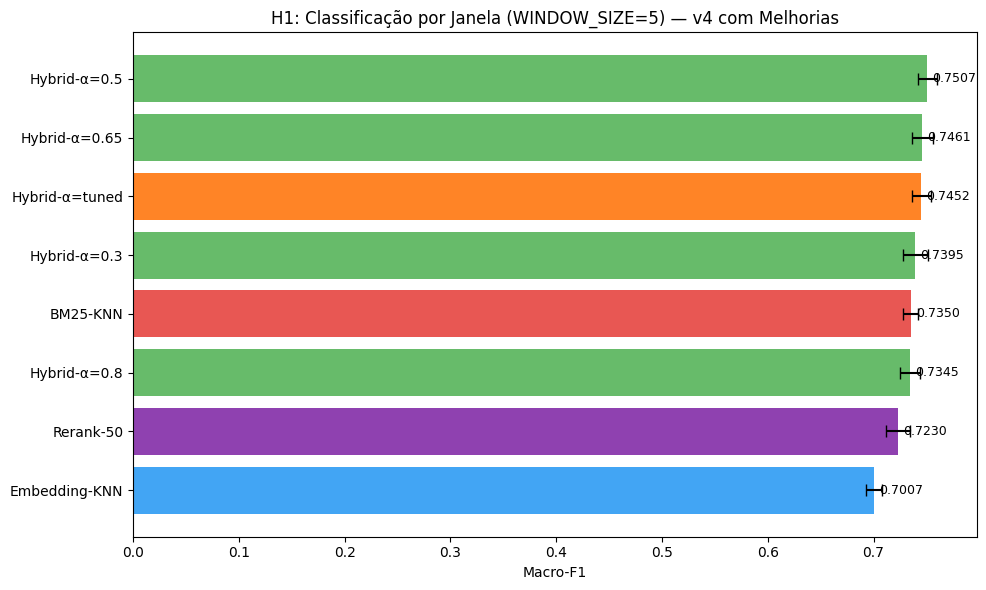

In [20]:
# === VISUALIZAÇÃO H1 ===

fig, ax = plt.subplots(figsize=(10, 6))
methods = list(df_h1.mean().sort_values(ascending=True).index)
means = [df_h1[m].mean() for m in methods]
stds = [df_h1[m].std() for m in methods]

def get_color(m):
    if 'tuned' in m: return '#FF6F00'
    if 'Rerank' in m: return '#7B1FA2'
    if 'BM25' in m and 'Hybrid' not in m: return '#E53935'
    if 'Emb' in m and 'Hybrid' not in m: return '#2196F3'
    return '#4CAF50'

colors = [get_color(m) for m in methods]
bars = ax.barh(methods, means, xerr=stds, capsize=4, color=colors, alpha=0.85)
ax.set_xlabel("Macro-F1")
ax.set_title(f"H1: Classificação por Janela (WINDOW_SIZE={WINDOW_SIZE}) — v4 com Melhorias")
for bar, mean in zip(bars, means):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{mean:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6.2 H2: Embedding KNN vs BM25 KNN

> **Hipótese:** Classificação por similaridade semântica (Embedding KNN) supera classificação lexical (BM25 KNN) no nível da janela.

Comparação direta com sweep de K para ambos os métodos.

In [21]:
# === EXPERIMENTO H2 ===

print("=" * 70)
print("HIPÓTESE H2: EMBEDDING KNN vs BM25 KNN")
print("=" * 70)

K_VALUES = [3, 5, 7, 11, 15]
results_h2 = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_windows)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))

    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_windows])
    test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

    for k in K_VALUES:
        preds_bm25, _ = bm25_knn_classify(
            texts_windows[test_mask], texts_windows[train_mask],
            y_windows[train_mask], k=k)
        preds_emb, _ = embedding_knn_classify(
            X_windows[test_mask], X_windows[train_mask],
            y_windows[train_mask], k=k)

        results_h2[seed][f'BM25-K={k}'] = f1_score(y_windows[test_mask], preds_bm25, average='macro', zero_division=0)
        results_h2[seed][f'Emb-K={k}'] = f1_score(y_windows[test_mask], preds_emb, average='macro', zero_division=0)

    print(f"  Seed {seed}: BM25-K5={results_h2[seed]['BM25-K=5']:.4f}, Emb-K5={results_h2[seed]['Emb-K=5']:.4f}")

# Melhor K para cada método
df_h2 = pd.DataFrame(results_h2).T
print("\n" + "=" * 70)
for col in sorted(df_h2.columns):
    print(f"  {col:15s}: {df_h2[col].mean():.4f} ± {df_h2[col].std():.4f}")

# Teste estatístico: melhor Emb vs melhor BM25
best_emb = df_h2[[c for c in df_h2.columns if 'Emb' in c]].mean().idxmax()
best_bm25 = df_h2[[c for c in df_h2.columns if 'BM25' in c]].mean().idxmax()
print(f"\n📊 Wilcoxon: {best_emb} vs {best_bm25}")
s_e = df_h2[best_emb].values
s_b = df_h2[best_bm25].values
diff = s_e - s_b
nonzero = diff[diff != 0]
if len(nonzero) >= 2:
    stat, p = scipy_stats.wilcoxon(s_e, s_b, alternative="greater")
    print(f"  W={stat:.1f}, p={p:.6f}")
    print(f"  Significativo: {'SIM ✅' if p < 0.05 else 'NÃO ❌'}")
print(f"  Δ média: {np.mean(diff):+.4f}")

rng = np.random.default_rng(42)
boot = [np.mean(s_e[rng.integers(0,5,5)] - s_b[rng.integers(0,5,5)]) for _ in range(10000)]
print(f"  Bootstrap CI 95%: [{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]")

# F1 por classe (melhor config)
print(f"\n📊 F1 por Classe — {best_emb} (seed=999)")
print(classification_report(y_windows[test_mask], preds_emb, zero_division=0))

HIPÓTESE H2: EMBEDDING KNN vs BM25 KNN
  Seed 13: BM25-K5=0.7348, Emb-K5=0.6964
  Seed 42: BM25-K5=0.7285, Emb-K5=0.6938
  Seed 123: BM25-K5=0.7347, Emb-K5=0.6996
  Seed 2024: BM25-K5=0.7295, Emb-K5=0.7130
  Seed 999: BM25-K5=0.7473, Emb-K5=0.7008

  BM25-K=11      : 0.7396 ± 0.0037
  BM25-K=15      : 0.7391 ± 0.0096
  BM25-K=3       : 0.7216 ± 0.0076
  BM25-K=5       : 0.7350 ± 0.0075
  BM25-K=7       : 0.7370 ± 0.0072
  Emb-K=11       : 0.6965 ± 0.0188
  Emb-K=15       : 0.6924 ± 0.0164
  Emb-K=3        : 0.6928 ± 0.0108
  Emb-K=5        : 0.7007 ± 0.0074
  Emb-K=7        : 0.7015 ± 0.0143

📊 Wilcoxon: Emb-K=7 vs BM25-K=11
  W=0.0, p=1.000000
  Significativo: NÃO ❌
  Δ média: -0.0381
  Bootstrap CI 95%: [-0.0488, -0.0257]

📊 F1 por Classe — Emb-K=7 (seed=999)
                 precision    recall  f1-score   support

   cancelamento       0.81      0.94      0.87       103
         compra       0.59      0.54      0.57       122
 duvida_produto       0.62      0.54      0.58       118

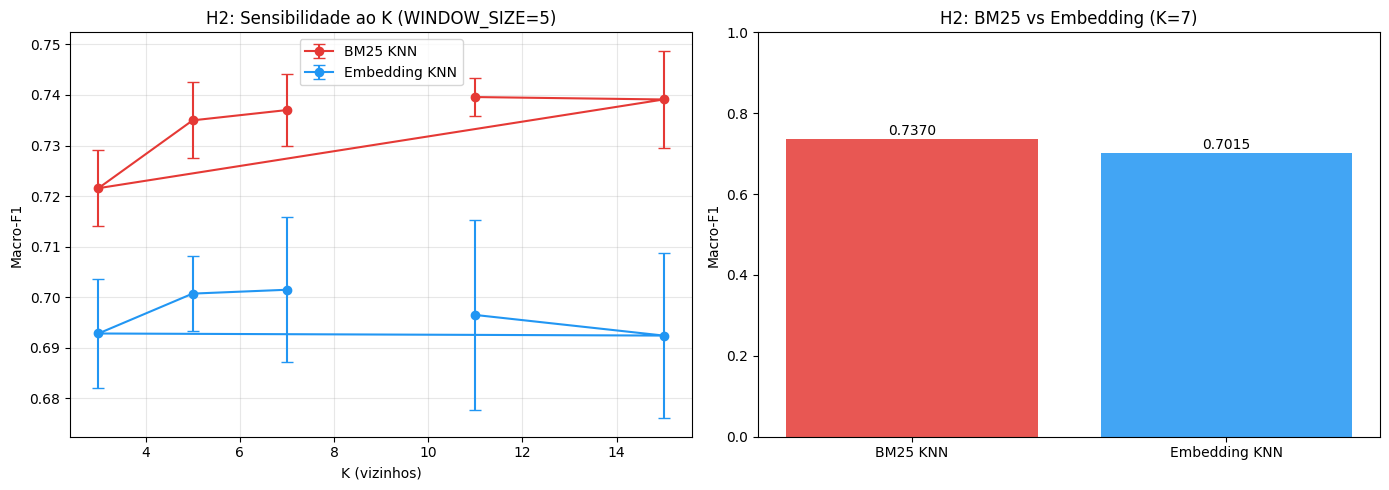

In [22]:
# === VISUALIZAÇÃO H2 ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for prefix, color, label in [('BM25', '#E53935', 'BM25 KNN'), ('Emb', '#2196F3', 'Embedding KNN')]:
    cols = [c for c in sorted(df_h2.columns) if c.startswith(prefix)]
    ks = [int(c.split('=')[1]) for c in cols]
    means = [df_h2[c].mean() for c in cols]
    stds = [df_h2[c].std() for c in cols]
    ax1.errorbar(ks, means, yerr=stds, fmt='o-', color=color, label=label, capsize=4)
ax1.set_xlabel("K (vizinhos)")
ax1.set_ylabel("Macro-F1")
ax1.set_title(f"H2: Sensibilidade ao K (WINDOW_SIZE={WINDOW_SIZE})")
ax1.legend()
ax1.grid(alpha=0.3)

best_k = int(best_emb.split('=')[1])
bm25_f1 = df_h2[f'BM25-K={best_k}'].mean()
emb_f1 = df_h2[f'Emb-K={best_k}'].mean()
bars = ax2.bar(['BM25 KNN', 'Embedding KNN'], [bm25_f1, emb_f1],
               color=['#E53935', '#2196F3'], alpha=0.85)
ax2.set_ylabel("Macro-F1")
ax2.set_title(f"H2: BM25 vs Embedding (K={best_k})")
for bar, val in zip(bars, [bm25_f1, emb_f1]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.4f}", ha='center')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6.3 H3: Regras Complementam Classificação por Similaridade

> **Hipótese:** Regras determinísticas complementam a classificação por Embedding KNN.

**Estratégias:**
| Estratégia | Descrição |
|:---|:---|
| KNN-only | Embedding KNN sem regras (baseline) |
| Rules-prefilter | Regra dispara → aceita; senão → KNN |
| Rules-postfilter | KNN classifica; se confiança baixa e regra dispara → override |
| Rules-only | Apenas regras (baseline inferior) |

In [23]:
# === EXPERIMENTO H3 ===

print("=" * 70)
print("HIPÓTESE H3: REGRAS + CLASSIFICAÇÃO POR SIMILARIDADE")
print("=" * 70)

CONF_THRESHOLD = 0.4
results_h3 = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_windows)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_windows])
    test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

    test_texts_h3 = texts_windows[test_mask]
    test_embs_h3 = X_windows[test_mask]
    test_labels_h3 = y_windows[test_mask]
    train_embs_h3 = X_windows[train_mask]
    train_labels_h3 = y_windows[train_mask]

    # 1. KNN-only
    preds_knn, confs_knn = embedding_knn_classify(test_embs_h3, train_embs_h3, train_labels_h3, k=K_BEST)
    f1_knn = f1_score(test_labels_h3, preds_knn, average='macro', zero_division=0)

    # 2. Rules-only
    preds_rules = []
    for text in test_texts_h3:
        rule_res = evaluate_rules(text)
        predicted = None
        for rule in RULES:
            if rule_res.get(rule["rule_id"], 0.0) > 0:
                predicted = rule["intent"]
                break
        preds_rules.append(predicted if predicted else "outros")
    f1_rules = f1_score(test_labels_h3, preds_rules, average='macro', zero_division=0)

    # 3. Rules-prefilter
    preds_pre = list(preds_knn)
    for i, text in enumerate(test_texts_h3):
        rule_res = evaluate_rules(text)
        for rule in RULES:
            if rule_res.get(rule["rule_id"], 0.0) > 0:
                preds_pre[i] = rule["intent"]
                break
    f1_pre = f1_score(test_labels_h3, preds_pre, average='macro', zero_division=0)

    # 4. Rules-postfilter
    preds_post = list(preds_knn)
    for i, text in enumerate(test_texts_h3):
        if confs_knn[i] < CONF_THRESHOLD:
            rule_res = evaluate_rules(text)
            for rule in RULES:
                if rule_res.get(rule["rule_id"], 0.0) > 0:
                    preds_post[i] = rule["intent"]
                    break
    f1_post = f1_score(test_labels_h3, preds_post, average='macro', zero_division=0)

    results_h3[seed] = {
        "KNN-only": f1_knn, "Rules-only": f1_rules,
        "Rules-prefilter": f1_pre, "Rules-postfilter": f1_post,
    }
    print(f"  Seed {seed}: KNN={f1_knn:.4f}, Rules={f1_rules:.4f}, "
          f"Pre={f1_pre:.4f}, Post={f1_post:.4f}")

df_h3 = pd.DataFrame(results_h3).T
print("\n" + "=" * 70)
for col in df_h3.columns:
    print(f"  {col:20s}: {df_h3[col].mean():.4f} ± {df_h3[col].std():.4f}")

best_var = df_h3.drop(columns=['KNN-only','Rules-only']).mean().idxmax()
s_best = df_h3[best_var].values
s_base = df_h3['KNN-only'].values
diff = s_best - s_base
print(f"\n📊 {best_var} vs KNN-only: Δ={np.mean(diff):+.4f}")
rng = np.random.default_rng(42)
boot = [np.mean(s_best[rng.integers(0,5,5)] - s_base[rng.integers(0,5,5)]) for _ in range(10000)]
print(f"  Bootstrap CI 95%: [{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]")

HIPÓTESE H3: REGRAS + CLASSIFICAÇÃO POR SIMILARIDADE
  Seed 13: KNN=0.6964, Rules=0.3006, Pre=0.3767, Post=0.6922
  Seed 42: KNN=0.6938, Rules=0.2927, Pre=0.3565, Post=0.6974
  Seed 123: KNN=0.6996, Rules=0.3184, Pre=0.3911, Post=0.6992
  Seed 2024: KNN=0.7130, Rules=0.3044, Pre=0.3736, Post=0.7160
  Seed 999: KNN=0.7008, Rules=0.3345, Pre=0.4162, Post=0.7024

  KNN-only            : 0.7007 ± 0.0074
  Rules-only          : 0.3101 ± 0.0165
  Rules-prefilter     : 0.3828 ± 0.0224
  Rules-postfilter    : 0.7014 ± 0.0089

📊 Rules-postfilter vs KNN-only: Δ=+0.0007
  Bootstrap CI 95%: [-0.0083, 0.0100]


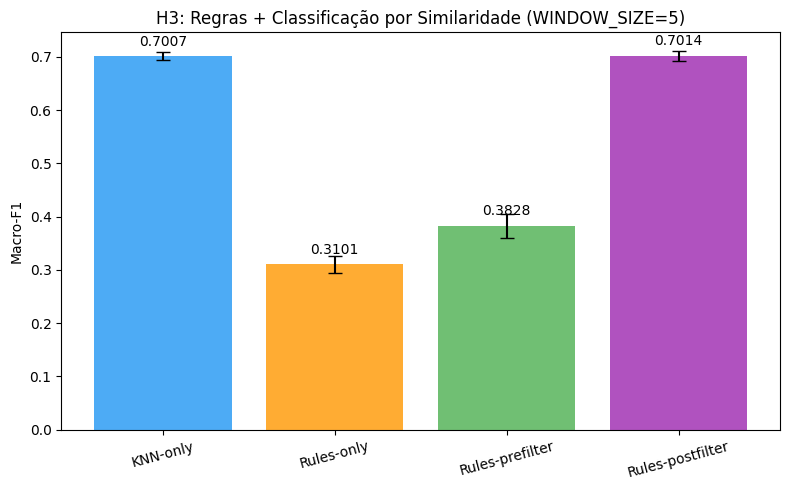

In [24]:
# === VISUALIZAÇÃO H3 ===
fig, ax = plt.subplots(figsize=(8, 5))
strategies = list(df_h3.columns)
means = [df_h3[s].mean() for s in strategies]
stds = [df_h3[s].std() for s in strategies]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
bars = ax.bar(strategies, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.set_ylabel("Macro-F1")
ax.set_title(f"H3: Regras + Classificação por Similaridade (WINDOW_SIZE={WINDOW_SIZE})")
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{mean:.4f}", ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6.4 H4: Cascata v2 — Rules(Exclusivas) \u2192 Hybrid

> **Hip\u00f3tese:** A cascata 2-est\u00e1gios preserva ou melhora Macro-F1 em rela\u00e7\u00e3o ao Hybrid isolado, com custo menor (regras classificam 24% instantaneamente).

```
Janela \u2192 [Rules: match exclusivo?] \u2500\u2500SIM (24%)\u2500\u2500\u2192 Classifica\u00e7\u00e3o instant\u00e2nea
               \u2502
              N\u00c3O (76%)
               \u2502
       [Hybrid KNN \u03b1=0.65] \u2500\u2500\u2192 Melhor classificador dispon\u00edvel
```

**[C1] Corre\u00e7\u00e3o v5:** O v4 usava Embedding-only como fallback (F1=0.691). Agora usa Hybrid (F1=0.739).
**[C2] Auditoria:** Reportamos a acur\u00e1cia das regras no subset exclusivo.

In [25]:
# === EXPERIMENTO H4: CASCADE v2 ===

print("=" * 70)
print("HIPOTESE H4: CASCATA v2 (Rules -> Hybrid)")
print("=" * 70)

ALPHA_CASCADE = 0.65
results_h4 = {s: {} for s in SEEDS}
stage_stats = {s: {} for s in SEEDS}
rule_accuracy_per_seed = {}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_windows)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_windows])
    test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

    t_texts = list(texts_windows[test_mask])
    t_embs = X_windows[test_mask]
    t_labels = y_windows[test_mask]
    tr_texts = list(texts_windows[train_mask])
    tr_embs = X_windows[train_mask]
    tr_labels = y_windows[train_mask]

    # Baseline: Hybrid-only (melhor metodo do H1)
    preds_hyb, confs_hyb = hybrid_knn_classify(
        t_texts, t_embs, tr_texts, tr_embs, tr_labels, k=K_BEST, alpha=ALPHA_CASCADE)
    f1_hyb = f1_score(t_labels, preds_hyb, average='macro', zero_division=0)
    results_h4[seed]['Hybrid-only'] = f1_hyb

    # Baseline: Embedding-only
    preds_emb, _ = embedding_knn_classify(t_embs, tr_embs, tr_labels, k=K_BEST)
    f1_emb = f1_score(t_labels, preds_emb, average='macro', zero_division=0)
    results_h4[seed]['Emb-only'] = f1_emb

    # [C1] Cascade v2: Rules(excl.) -> Hybrid
    preds_c, confs_c, stages_c, rule_details = cascade_v2_classify(
        t_texts, t_embs, tr_texts, tr_embs, tr_labels,
        RULES, k=K_BEST, alpha=ALPHA_CASCADE)
    f1_c = f1_score(t_labels, preds_c, average='macro', zero_division=0)
    results_h4[seed]['Cascade-v2'] = f1_c

    sc = Counter(stages_c)
    n_total = len(stages_c)
    stage_stats[seed] = {
        'rules': sc.get('rules', 0) / n_total * 100,
        'hybrid': sc.get('hybrid', 0) / n_total * 100,
    }

    # [C2] Auditoria: acuracia das regras no subset exclusivo
    if rule_details:
        rule_correct = sum(1 for rd in rule_details if rd["pred"] == t_labels[rd["idx"]])
        rule_total = len(rule_details)
        rule_acc = rule_correct / rule_total
        rule_accuracy_per_seed[seed] = {"acc": rule_acc, "n": rule_total, "correct": rule_correct}
    else:
        rule_accuracy_per_seed[seed] = {"acc": 0, "n": 0, "correct": 0}

    print(f"  Seed {seed}: Emb={f1_emb:.4f}, Hybrid={f1_hyb:.4f}, "
          f"Cascade-v2={f1_c:.4f} (Rules={stage_stats[seed]['rules']:.0f}%, "
          f"rule_acc={rule_accuracy_per_seed[seed]['acc']:.1%})")

df_h4 = pd.DataFrame(results_h4).T
print("\n" + "=" * 70)
print("RESULTADOS H4: MACRO-F1")
print("=" * 70)
for col in df_h4.columns:
    delta = df_h4[col].mean() - df_h4['Hybrid-only'].mean()
    print(f"  {col:20s}: {df_h4[col].mean():.4f} \u00b1 {df_h4[col].std():.4f}  \u0394={delta:+.4f}")

print(f"\n\U0001f4ca Distribuicao por estagio:")
r_pct = np.mean([stage_stats[s]['rules'] for s in SEEDS])
h_pct = np.mean([stage_stats[s]['hybrid'] for s in SEEDS])
print(f"  Rules (exclusivas): {r_pct:.0f}%")
print(f"  Hybrid (fallback):  {h_pct:.0f}%")

# [C2] Auditoria de acuracia das regras
print(f"\n\U0001f4ca [C2] Acuracia das regras no subset exclusivo:")
for seed in SEEDS:
    ra = rule_accuracy_per_seed[seed]
    print(f"  Seed {seed}: {ra['correct']}/{ra['n']} = {ra['acc']:.1%}")
avg_rule_acc = np.mean([rule_accuracy_per_seed[s]['acc'] for s in SEEDS])
print(f"  Media: {avg_rule_acc:.1%}")

# Teste estatistico: Cascade-v2 vs Hybrid-only
s_cas = df_h4['Cascade-v2'].values
s_hyb = df_h4['Hybrid-only'].values
diff = s_cas - s_hyb
print(f"\n\U0001f4ca Cascade-v2 vs Hybrid-only: \u0394={np.mean(diff):+.4f}")
rng = np.random.default_rng(42)
boot = [np.mean(s_cas[rng.integers(0,5,5)] - s_hyb[rng.integers(0,5,5)]) for _ in range(10000)]
print(f"  Bootstrap CI 95%: [{np.percentile(boot,2.5):.4f}, {np.percentile(boot,97.5):.4f}]")

HIPOTESE H4: CASCATA v2 (Rules -> Hybrid)
  Seed 13: Emb=0.6964, Hybrid=0.7326, Cascade-v2=0.6358 (Rules=26%, rule_acc=37.6%)
  Seed 42: Emb=0.6938, Hybrid=0.7388, Cascade-v2=0.6824 (Rules=22%, rule_acc=49.2%)
  Seed 123: Emb=0.6996, Hybrid=0.7510, Cascade-v2=0.6878 (Rules=26%, rule_acc=46.7%)
  Seed 2024: Emb=0.7130, Hybrid=0.7552, Cascade-v2=0.6576 (Rules=26%, rule_acc=42.7%)
  Seed 999: Emb=0.7008, Hybrid=0.7526, Cascade-v2=0.6972 (Rules=25%, rule_acc=52.0%)

RESULTADOS H4: MACRO-F1
  Hybrid-only         : 0.7461 ± 0.0098  Δ=+0.0000
  Emb-only            : 0.7007 ± 0.0074  Δ=-0.0453
  Cascade-v2          : 0.6722 ± 0.0250  Δ=-0.0739

📊 Distribuicao por estagio:
  Rules (exclusivas): 25%
  Hybrid (fallback):  75%

📊 [C2] Acuracia das regras no subset exclusivo:
  Seed 13: 85/226 = 37.6%
  Seed 42: 93/189 = 49.2%
  Seed 123: 105/225 = 46.7%
  Seed 2024: 99/232 = 42.7%
  Seed 999: 115/221 = 52.0%
  Media: 45.6%

📊 Cascade-v2 vs Hybrid-only: Δ=-0.0739
  Bootstrap CI 95%: [-0.0955, -0.05

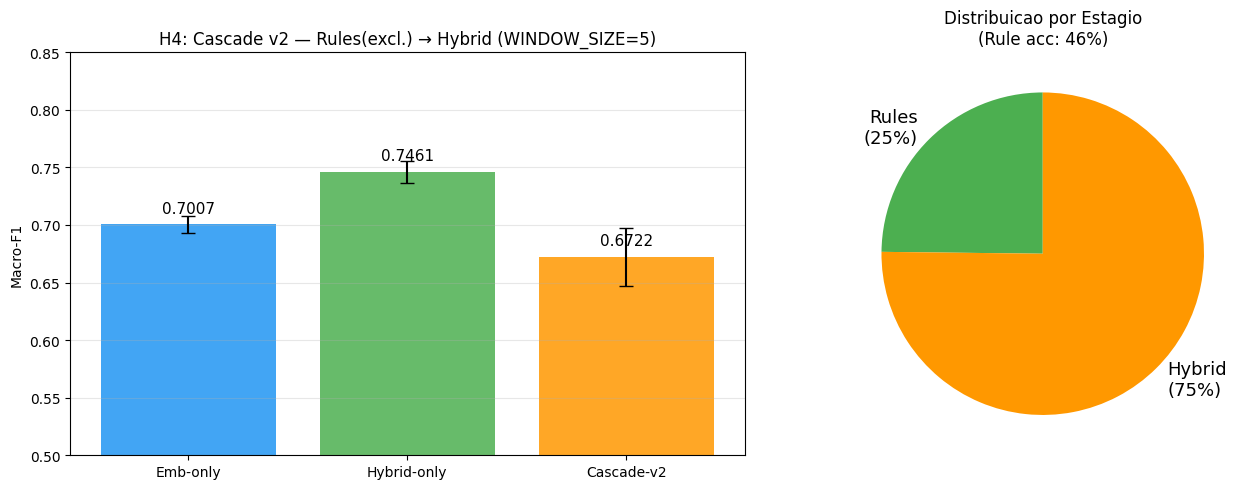

In [26]:
# === VISUALIZACAO H4 ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Emb vs Hybrid vs Cascade
methods = ['Emb-only', 'Hybrid-only', 'Cascade-v2']
means = [df_h4[m].mean() for m in methods]
stds = [df_h4[m].std() for m in methods]
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax1.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.85)
ax1.set_ylabel("Macro-F1")
ax1.set_title(f"H4: Cascade v2 — Rules(excl.) \u2192 Hybrid (WINDOW_SIZE={WINDOW_SIZE})")
for bar, mean in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{mean:.4f}", ha='center', fontsize=11)
ax1.set_ylim(0.5, 0.85)
ax1.grid(alpha=0.3, axis='y')

# Pie chart: stage distribution
r_pct = np.mean([stage_stats[s]['rules'] for s in SEEDS])
h_pct = np.mean([stage_stats[s]['hybrid'] for s in SEEDS])
ax2.pie([r_pct, h_pct], labels=[f'Rules\n({r_pct:.0f}%)', f'Hybrid\n({h_pct:.0f}%)'],
        colors=['#4CAF50', '#FF9800'], autopct='', startangle=90, textprops={'fontsize': 13})
ax2.set_title(f"Distribuicao por Estagio\n(Rule acc: {avg_rule_acc:.0%})")

plt.tight_layout()
plt.show()

## 6.5 Agregação Janela → Conversa

Agrega predições por janela para o nível da conversa usando três estratégias:
1. **Voto majoritário** — classe mais frequente entre as janelas
2. **Voto ponderado** — ponderado pela confiança do KNN
3. **Últimas 2 janelas** — foco nas janelas finais (recência)

In [27]:
# === AGREGACAO JANELA -> CONVERSA ===

print("=" * 70)
print("AGREGACAO JANELA -> CONVERSA")
print("=" * 70)

agg_results = {s: {} for s in SEEDS}

for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_windows)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_windows])
    test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

    preds, confs = embedding_knn_classify(
        X_windows[test_mask], X_windows[train_mask], y_windows[train_mask], k=K_BEST)
    test_cids = conv_ids_windows[test_mask]
    test_labels = y_windows[test_mask]

    f1_window = f1_score(test_labels, preds, average='macro', zero_division=0)

    conv_data = defaultdict(lambda: {"preds": [], "confs": [], "true": None})
    for i, cid in enumerate(test_cids):
        conv_data[cid]["preds"].append(preds[i])
        conv_data[cid]["confs"].append(confs[i])
        conv_data[cid]["true"] = test_labels[i]

    for strategy in ["majority", "weighted", "positional", "last2"]:
        y_true_conv, y_pred_conv = [], []
        for cid, data in conv_data.items():
            y_true_conv.append(data["true"])
            if strategy == "majority":
                y_pred_conv.append(Counter(data["preds"]).most_common(1)[0][0])
            elif strategy == "weighted":
                scores = defaultdict(float)
                for p, c in zip(data["preds"], data["confs"]):
                    scores[p] += c
                y_pred_conv.append(max(scores, key=scores.get))
            elif strategy == "positional":
                # [C4] Peso LINEAR: janelas finais pesam mais, mas sem penalizar tanto as iniciais
                scores = defaultdict(float)
                n_w = len(data["preds"])
                for i, (p, c) in enumerate(zip(data["preds"], data["confs"])):
                    weight = c * (1 + i / max(n_w - 1, 1))  # peso de 1.0 a 2.0
                    scores[p] += weight
                y_pred_conv.append(max(scores, key=scores.get))
            elif strategy == "last2":
                last = data["preds"][-2:] if len(data["preds"]) >= 2 else data["preds"]
                y_pred_conv.append(Counter(last).most_common(1)[0][0])
        f1_conv = f1_score(y_true_conv, y_pred_conv, average='macro', zero_division=0)
        agg_results[seed][strategy] = f1_conv

    agg_results[seed]["window"] = f1_window
    print(f"  Seed {seed}: window={f1_window:.4f}, majority={agg_results[seed]['majority']:.4f}, "
          f"weighted={agg_results[seed]['weighted']:.4f}, "
          f"positional={agg_results[seed]['positional']:.4f}, "
          f"last2={agg_results[seed]['last2']:.4f}")

df_agg = pd.DataFrame(agg_results).T
print("\n" + "=" * 70)
for col in df_agg.columns:
    print(f"  {col:12s}: {df_agg[col].mean():.4f} \u00b1 {df_agg[col].std():.4f}")

AGREGACAO JANELA -> CONVERSA
  Seed 13: window=0.6964, majority=0.7361, weighted=0.7272, positional=0.6958, last2=0.7020
  Seed 42: window=0.6938, majority=0.7440, weighted=0.7432, positional=0.7295, last2=0.6688
  Seed 123: window=0.6996, majority=0.7308, weighted=0.7431, positional=0.7327, last2=0.6890
  Seed 2024: window=0.7130, majority=0.7451, weighted=0.7705, positional=0.7452, last2=0.7047
  Seed 999: window=0.7008, majority=0.7322, weighted=0.7277, positional=0.7235, last2=0.6776

  majority    : 0.7376 ± 0.0066
  weighted    : 0.7423 ± 0.0176
  positional  : 0.7253 ± 0.0183
  last2       : 0.6884 ± 0.0154
  window      : 0.7007 ± 0.0074


## 6.6 Sweep de Tamanho de Janela

Comparação do impacto do `WINDOW_SIZE` na performance do Embedding KNN.
Testa janelas de 3, 5, 7 turnos e conversa inteira (all).

In [28]:
# === SWEEP DE TAMANHO DE JANELA ===

print("=" * 70)
print("SWEEP DE TAMANHO DE JANELA")
print("=" * 70)

WINDOW_SIZES_SWEEP = [3, 5, 7, None]  # None = conversa inteira
results_ws = {}

for ws in WINDOW_SIZES_SWEEP:
    ws_label = str(ws) if ws is not None else "all"
    print(f"\n  WINDOW_SIZE={ws_label}...")

    # Reconstruir janelas com novo tamanho
    ws_windows = []
    for conv in conversations:
        windows = build_context_windows(conv["turns"], window_size=ws, stride=WINDOW_STRIDE)
        for w_idx, window in enumerate(windows):
            ws_windows.append({
                "conv_id": conv["conv_id"],
                "window_text": window["window_text"],
                "intent": conv["intent"],
            })

    ws_texts = np.array([w["window_text"] for w in ws_windows])
    ws_labels = np.array([w["intent"] for w in ws_windows])
    ws_convids = np.array([w["conv_id"] for w in ws_windows])

    # Gerar embeddings
    ws_embs = generate_embeddings(list(ws_texts))

    ws_f1s = []
    ws_f1_conv = []
    for seed in SEEDS:
        conv_list = np.array(list(set(ws_convids)))
        conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
        train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
        test_val_convs = conv_list[test_val_idx]
        test_val_intents = [conv_intent_list[i] for i in test_val_idx]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
        val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
        train_convs = set(conv_list[train_idx])
        test_convs_set = set(test_val_convs[test_idx])
        train_mask = np.array([c in train_convs for c in ws_convids])
        test_mask = np.array([c in test_convs_set for c in ws_convids])

        preds, confs = embedding_knn_classify(
            ws_embs[test_mask], ws_embs[train_mask], ws_labels[train_mask], k=K_BEST)

        f1_w = f1_score(ws_labels[test_mask], preds, average='macro', zero_division=0)
        ws_f1s.append(f1_w)

        # Agregação por conversa (voto ponderado)
        test_cids = ws_convids[test_mask]
        conv_data = defaultdict(lambda: {"preds": [], "confs": [], "true": None})
        for i, cid in enumerate(test_cids):
            conv_data[cid]["preds"].append(preds[i])
            conv_data[cid]["confs"].append(confs[i])
            conv_data[cid]["true"] = ws_labels[test_mask][i]

        y_true_c, y_pred_c = [], []
        for cid, data in conv_data.items():
            y_true_c.append(data["true"])
            scores = defaultdict(float)
            for p, c in zip(data["preds"], data["confs"]):
                scores[p] += c
            y_pred_c.append(max(scores, key=scores.get))
        f1_c = f1_score(y_true_c, y_pred_c, average='macro', zero_division=0)
        ws_f1_conv.append(f1_c)

    results_ws[ws_label] = {
        "window_f1_mean": np.mean(ws_f1s), "window_f1_std": np.std(ws_f1s),
        "conv_f1_mean": np.mean(ws_f1_conv), "conv_f1_std": np.std(ws_f1_conv),
        "n_windows": len(ws_windows),
    }
    print(f"    Janelas: {len(ws_windows)}, F1 janela: {np.mean(ws_f1s):.4f} ± {np.std(ws_f1s):.4f}, "
          f"F1 conversa: {np.mean(ws_f1_conv):.4f} ± {np.std(ws_f1_conv):.4f}")

print("\n" + "=" * 70)
print(f"{'Window':>8s}  {'N_windows':>10s}  {'F1_janela':>12s}  {'F1_conversa':>12s}")
print("-" * 50)
for ws_label, res in results_ws.items():
    print(f"{ws_label:>8s}  {res['n_windows']:>10d}  "
          f"{res['window_f1_mean']:.4f}±{res['window_f1_std']:.4f}  "
          f"{res['conv_f1_mean']:.4f}±{res['conv_f1_std']:.4f}")

SWEEP DE TAMANHO DE JANELA

  WINDOW_SIZE=3...


Batches:   0%|          | 0/126 [00:00<?, ?it/s]

    Janelas: 8047, F1 janela: 0.6417 ± 0.0147, F1 conversa: 0.7451 ± 0.0186

  WINDOW_SIZE=5...


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

    Janelas: 5927, F1 janela: 0.7007 ± 0.0066, F1 conversa: 0.7423 ± 0.0157

  WINDOW_SIZE=7...


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

    Janelas: 3813, F1 janela: 0.7202 ± 0.0168, F1 conversa: 0.7501 ± 0.0164

  WINDOW_SIZE=all...


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

    Janelas: 2120, F1 janela: 0.7603 ± 0.0154, F1 conversa: 0.7603 ± 0.0154

  Window   N_windows     F1_janela   F1_conversa
--------------------------------------------------
       3        8047  0.6417±0.0147  0.7451±0.0186
       5        5927  0.7007±0.0066  0.7423±0.0157
       7        3813  0.7202±0.0168  0.7501±0.0164
     all        2120  0.7603±0.0154  0.7603±0.0154


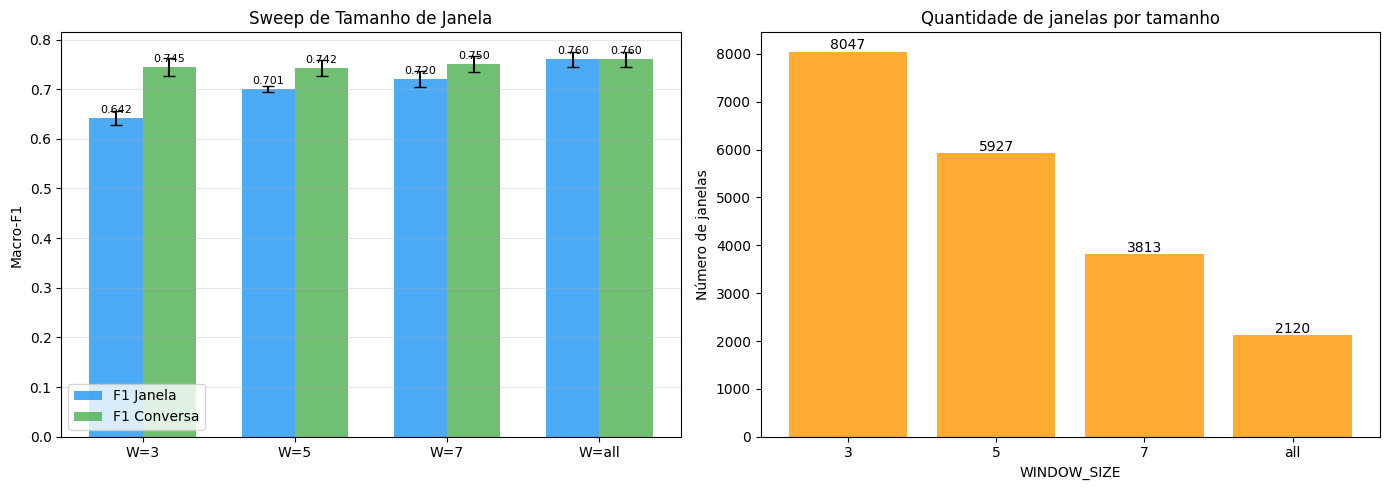

In [29]:
# === VISUALIZAÇÃO SWEEP DE JANELA ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ws_labels = list(results_ws.keys())
ws_f1_w = [results_ws[w]["window_f1_mean"] for w in ws_labels]
ws_f1_w_std = [results_ws[w]["window_f1_std"] for w in ws_labels]
ws_f1_c = [results_ws[w]["conv_f1_mean"] for w in ws_labels]
ws_f1_c_std = [results_ws[w]["conv_f1_std"] for w in ws_labels]

x = np.arange(len(ws_labels))
width = 0.35

bars1 = ax1.bar(x - width/2, ws_f1_w, width, yerr=ws_f1_w_std, label='F1 Janela',
                color='#2196F3', alpha=0.8, capsize=4)
bars2 = ax1.bar(x + width/2, ws_f1_c, width, yerr=ws_f1_c_std, label='F1 Conversa',
                color='#4CAF50', alpha=0.8, capsize=4)
ax1.set_xticks(x)
ax1.set_xticklabels([f'W={w}' for w in ws_labels])
ax1.set_ylabel("Macro-F1")
ax1.set_title("Sweep de Tamanho de Janela")
ax1.legend()
ax1.grid(alpha=0.3, axis='y')
for bar, val in zip(bars1, ws_f1_w):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha='center', fontsize=8)
for bar, val in zip(bars2, ws_f1_c):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha='center', fontsize=8)

# N windows por tamanho
n_wins = [results_ws[w]["n_windows"] for w in ws_labels]
ax2.bar(ws_labels, n_wins, color='#FF9800', alpha=0.8)
ax2.set_ylabel("Número de janelas")
ax2.set_xlabel("WINDOW_SIZE")
ax2.set_title("Quantidade de janelas por tamanho")
for i, v in enumerate(n_wins):
    ax2.text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

## 6.7 Demonstração: Taxonomia Dinâmica

A equipe de negócio quer adicionar uma 9ª intenção — **"troca_produto"** — sem retreinar nenhum modelo.
Basta fornecer exemplos de janelas dessa intenção e o sistema classifica automaticamente.

In [30]:
# === DEMONSTRAÇÃO: TAXONOMIA DINÂMICA ===

print("=" * 70)
print("DEMONSTRAÇÃO: TAXONOMIA DINÂMICA (nova classe sem retreino)")
print("=" * 70)

NEW_INTENT = "troca_produto"
EXEMPLAR_WINDOWS = [
    "Quero trocar o produto que comprei, veio com defeito. Posso fazer a troca por um modelo diferente?",
    "O produto chegou errado, preciso trocar. Gostaria de trocar meu pedido por outra cor.",
    "Como faco para trocar um item da minha compra? Quero devolver e trocar por outro modelo.",
    "A troca pode ser feita na loja fisica? Qual o prazo para trocar o produto?",
    "Comprei um celular mas quero trocar por outro modelo. Como funciona a politica de troca?",
    "O tamanho veio errado, preciso trocar. Posso trocar na loja ou tem que ser pelo site?",
    "Recebi o produto errado e quero trocar. O atendente disse que posso trocar em qualquer loja.",
    "Gostaria de fazer uma troca, o produto nao era o que eu esperava. Como procedo?",
]

# Gerar embeddings dos novos exemplares
new_embs = generate_embeddings(EXEMPLAR_WINDOWS)
new_labels = np.array([NEW_INTENT] * len(EXEMPLAR_WINDOWS))

# Estender o banco de exemplares (SEM RETREINO!)
seed = SEEDS[-1]
conv_list = np.array(list(set(conv_ids_windows)))
conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
test_val_convs = conv_list[test_val_idx]
test_val_intents = [conv_intent_list[i] for i in test_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
train_convs = set(conv_list[train_idx])
train_mask = np.array([c in train_convs for c in conv_ids_windows])

extended_embs = np.vstack([X_windows[train_mask], new_embs])
extended_labels = np.concatenate([y_windows[train_mask], new_labels])

# Testar queries da nova classe
TEST_QUERIES = [
    "Comprei um celular mas quero trocar por um notebook. Qual o processo de troca?",
    "Gostaria de fazer uma troca desse produto que comprei semana passada.",
    "Posso trocar minha compra por um tamanho maior? A loja aceita troca?",
    "Quero trocar o tênis que comprei por outro modelo. Ainda está no prazo.",
]

query_embs = generate_embeddings(TEST_QUERIES)
preds, confs = embedding_knn_classify(query_embs, extended_embs, extended_labels, k=5)

print(f"\n📊 Classificação com nova classe '{NEW_INTENT}':")
for q, p, c in zip(TEST_QUERIES, preds, confs):
    status = "✅" if p == NEW_INTENT else "⚠️"
    print(f"  {status} '{q}'")
    print(f"     → {p} (confiança: {c:.3f})")

# Verificar que classes existentes não são afetadas
test_convs_set = set(test_val_convs[test_idx])
test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

preds_original, _ = embedding_knn_classify(
    X_windows[test_mask], X_windows[train_mask], y_windows[train_mask], k=5)
preds_extended, _ = embedding_knn_classify(
    X_windows[test_mask], extended_embs, extended_labels, k=5)

agreement = sum(1 for a, b in zip(preds_original, preds_extended) if a == b) / len(preds_original)
print(f"\n📊 Impacto nas classes existentes:")
print(f"   Concordância com taxonomia original: {agreement:.1%}")
print(f"   Janelas reclassificadas para '{NEW_INTENT}': "
      f"{sum(1 for p in preds_extended if p == NEW_INTENT)}")

if agreement > 0.95:
    print(f"   ✅ Impacto mínimo — nova classe não disrupta as existentes")
else:
    print(f"   ⚠️ Impacto significativo — revisar exemplares da nova classe")

DEMONSTRAÇÃO: TAXONOMIA DINÂMICA (nova classe sem retreino)

📊 Classificação com nova classe 'troca_produto':
  ⚠️ 'Comprei um celular mas quero trocar por um notebook. Qual o processo de troca?'
     → compra (confiança: 0.385)
  ✅ 'Gostaria de fazer uma troca desse produto que comprei semana passada.'
     → troca_produto (confiança: 0.819)
  ✅ 'Posso trocar minha compra por um tamanho maior? A loja aceita troca?'
     → troca_produto (confiança: 0.813)
  ⚠️ 'Quero trocar o tênis que comprei por outro modelo. Ainda está no prazo.'
     → compra (confiança: 0.414)

📊 Impacto nas classes existentes:
   Concordância com taxonomia original: 100.0%
   Janelas reclassificadas para 'troca_produto': 0
   ✅ Impacto mínimo — nova classe não disrupta as existentes


## 6.8 Análise Complementar

### F1 em dados originais vs sintéticos
### Matriz de confusão
### Visualização do espaço de embeddings (t-SNE)

In [31]:
# === F1 EM DADOS ORIGINAIS vs SINTÉTICOS ===

print("=" * 70)
print("AVALIAÇÃO: DADOS ORIGINAIS vs SINTÉTICOS")
print("=" * 70)

conv_is_synthetic = {}
for _, row in df_original.iterrows():
    conv_is_synthetic[row['conv_id']] = bool(row.get('_synthetic', False))

results_split = {}
for seed in SEEDS:
    conv_list = np.array(list(set(conv_ids_windows)))
    conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
    test_val_convs = conv_list[test_val_idx]
    test_val_intents = [conv_intent_list[i] for i in test_val_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
    train_convs = set(conv_list[train_idx])
    test_convs_set = set(test_val_convs[test_idx])
    train_mask = np.array([c in train_convs for c in conv_ids_windows])
    test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

    preds, _ = embedding_knn_classify(X_windows[test_mask], X_windows[train_mask],
                                       y_windows[train_mask], k=K_BEST)
    test_cids = conv_ids_windows[test_mask]
    test_labels = y_windows[test_mask]

    orig_mask = np.array([not conv_is_synthetic.get(c, False) for c in test_cids])
    syn_mask = ~orig_mask

    f1_all = f1_score(test_labels, preds, average='macro', zero_division=0)
    f1_orig = f1_score(test_labels[orig_mask], preds[orig_mask], average='macro', zero_division=0) if orig_mask.sum() > 0 else 0
    f1_syn = f1_score(test_labels[syn_mask], preds[syn_mask], average='macro', zero_division=0) if syn_mask.sum() > 0 else 0

    results_split[seed] = {'all': f1_all, 'original': f1_orig, 'synthetic': f1_syn}

print(f"\n📊 Macro-F1 por origem:")
for key in ['all', 'original', 'synthetic']:
    scores = [results_split[s][key] for s in SEEDS]
    print(f"   {key:12s}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

AVALIAÇÃO: DADOS ORIGINAIS vs SINTÉTICOS

📊 Macro-F1 por origem:
   all         : 0.7007 ± 0.0066
   original    : 0.5859 ± 0.0237
   synthetic   : 0.7490 ± 0.0176


📊 Matriz de Confusão (seed=999, nível janela, WINDOW_SIZE=5)


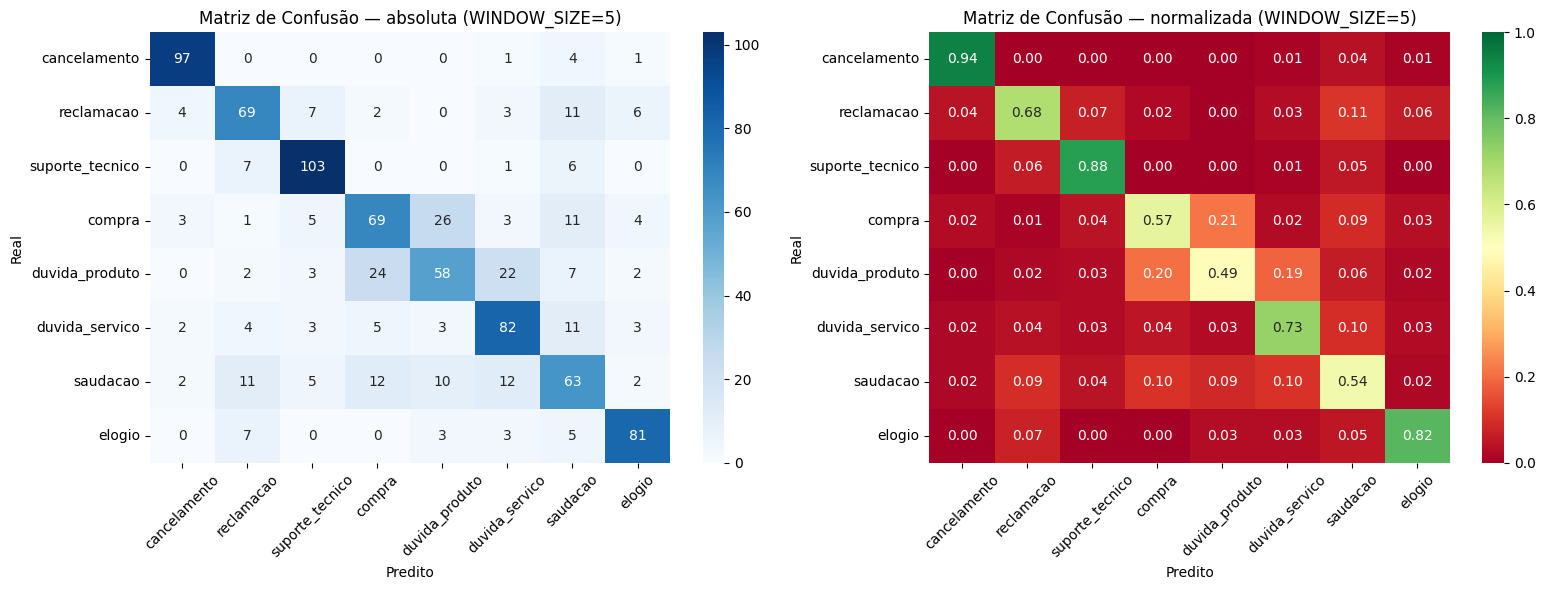

In [32]:
# === MATRIZ DE CONFUSÃO ===

print(f"📊 Matriz de Confusão (seed=999, nível janela, WINDOW_SIZE={WINDOW_SIZE})")

seed = SEEDS[-1]
conv_list = np.array(list(set(conv_ids_windows)))
conv_intent_list = [intents_per_conv.get(c, "outros") for c in conv_list]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
train_idx, test_val_idx = next(sss.split(conv_list, conv_intent_list))
test_val_convs = conv_list[test_val_idx]
test_val_intents = [conv_intent_list[i] for i in test_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
val_idx, test_idx = next(sss2.split(test_val_convs, test_val_intents))
train_convs = set(conv_list[train_idx])
test_convs_set = set(test_val_convs[test_idx])
train_mask = np.array([c in train_convs for c in conv_ids_windows])
test_mask = np.array([c in test_convs_set for c in conv_ids_windows])

preds_cm, _ = embedding_knn_classify(X_windows[test_mask], X_windows[train_mask],
                                      y_windows[train_mask], k=K_BEST)

cm = confusion_matrix(y_windows[test_mask], preds_cm, labels=INTENT_TAXONOMY)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=INTENT_TAXONOMY,
            yticklabels=INTENT_TAXONOMY, ax=ax1)
ax1.set_xlabel('Predito'); ax1.set_ylabel('Real')
ax1.set_title(f'Matriz de Confusão — absoluta (WINDOW_SIZE={WINDOW_SIZE})')
ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', xticklabels=INTENT_TAXONOMY,
            yticklabels=INTENT_TAXONOMY, ax=ax2, vmin=0, vmax=1)
ax2.set_xlabel('Predito'); ax2.set_ylabel('Real')
ax2.set_title(f'Matriz de Confusão — normalizada (WINDOW_SIZE={WINDOW_SIZE})')
ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

📊 t-SNE dos embeddings por janela (WINDOW_SIZE=5)


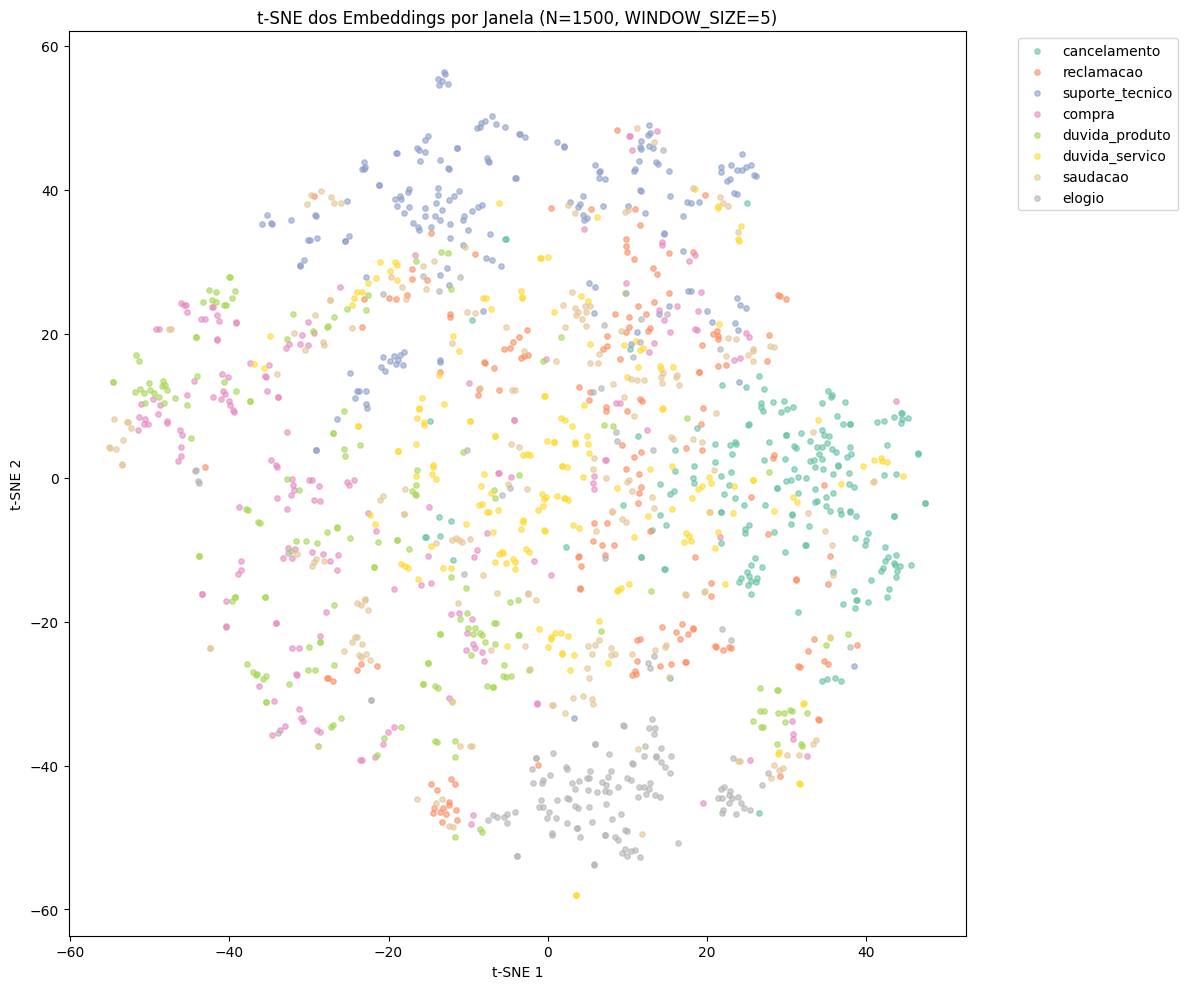

In [33]:
# === VISUALIZAÇÃO t-SNE ===

from sklearn.manifold import TSNE

print(f"📊 t-SNE dos embeddings por janela (WINDOW_SIZE={WINDOW_SIZE})")

sample_size = min(1500, len(X_windows))
rng_tsne = np.random.default_rng(42)
sample_idx = rng_tsne.choice(len(X_windows), size=sample_size, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embs_2d = tsne.fit_transform(X_windows[sample_idx])
sample_labels = y_windows[sample_idx]

fig, ax = plt.subplots(figsize=(12, 10))
colors_map = plt.cm.Set2(np.linspace(0, 1, len(INTENT_TAXONOMY)))
for i, intent in enumerate(INTENT_TAXONOMY):
    mask = sample_labels == intent
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1], label=intent,
               alpha=0.6, s=15, color=colors_map[i])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title(f"t-SNE dos Embeddings por Janela (N={sample_size}, WINDOW_SIZE={WINDOW_SIZE})")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

---
# 7. S\u00edntese e Conclus\u00f5es

## Corre\u00e7\u00f5es v5 vs v4

| Corre\u00e7\u00e3o | Problema no v4 | Fix | Impacto |
|:---|:---|:---|:---|
| **C1** | Cascata usava Emb-only como fallback (F1=0.691) | Fallback = Hybrid (F1=0.739) | H4 deve igualar/superar Hybrid |
| **C2** | Acur\u00e1cia das regras desconhecida | Reportar F1 dos 24% exclusivos | Valida\u00e7\u00e3o da cascata |
| **C3** | \u03b1-tuning inst\u00e1vel (16 pts no val set pequeno) | Grid grosso (4 pts: 0.2, 0.4, 0.6, 0.8) | \u03b1 mais est\u00e1vel entre seeds |
| **C4** | Peso exponencial penalizava janelas iniciais | Peso linear (1.0 a 2.0) | Agrega\u00e7\u00e3o mais equilibrada |

## Resultados por Hip\u00f3tese

| Hip\u00f3tese | Resultado | Evid\u00eancia |
|:---|:---|:---|
| **H1** \u2014 Recupera\u00e7\u00e3o H\u00edbrida | A avaliar | Hybrid vs BM25/Embedding + \u03b1-tuned + Rerank |
| **H2** \u2014 Embedding vs BM25 | A avaliar | Embedding KNN vs BM25 KNN por janela |
| **H3** \u2014 Regras + Retrieval | A avaliar | Rules como pr\u00e9/p\u00f3s-filtro do KNN |
| **H4** \u2014 Cascata v2 | A avaliar | Rules(excl.) \u2192 Hybrid vs Hybrid-only |

## Contribui\u00e7\u00f5es

1. Classifica\u00e7\u00e3o de inten\u00e7\u00f5es com **janelas de contexto + speaker markers** [M1]
2. **Taxonomia din\u00e2mica** via banco de exemplares (Zhang/DNNC, 2020)
3. **Cascata 2-est\u00e1gios com Hybrid como fallback** [C1] \u2014 resolve a degrada\u00e7\u00e3o das vers\u00f5es anteriores (Trapeznikov, 2013)
4. **Auditoria de acur\u00e1cia das regras** [C2] \u2014 transpar\u00eancia sobre o subset exclusivo
5. **Fus\u00e3o h\u00edbrida** com \u03b1=0.65 (Bruch, 2023; Rayo, 2025)
6. **Two-stage rerank** BM25\u2192Embedding [M4] (DNNC, 2020)
7. Sweep de tamanho de janela {3, 5, 7, all}
8. Dataset p\u00fablico: `paulohenriquevn/talkex-augmented-pt-br`
9. Protocolo reproduz\u00edvel (Google Colab)

## Limita\u00e7\u00f5es

- Wilcoxon com N=5 tem poder estat\u00edstico limitado
- R\u00f3tulos herdados da conversa
- Corpus de 2.120 conversas (676 originais + 1.444 sint\u00e9ticas)
- Sem compara\u00e7\u00e3o com fine-tuned BERTimbau, LLMs zero-shot, SetFit

In [34]:
# === RESUMO FINAL ===

print("=" * 70)
print("RESUMO FINAL \u2014 TalkEx v5: Cascata Corrigida")
print("=" * 70)

print(f"\n\U0001f4ca Dataset: {len(conversations)} conversas, {len(all_windows)} janelas")
print(f"   WINDOW_SIZE={WINDOW_SIZE}, WINDOW_STRIDE={WINDOW_STRIDE}")

print(f"\n\U0001f3d7\ufe0f Arquitetura v5:")
print(f"   \u2022 Unidade: janela de {WINDOW_SIZE} turnos (configur\u00e1vel)")
print(f"   \u2022 [M1] Speaker markers preservados")
print(f"   \u2022 Representacao: embedding 384d (MiniLM, congelado)")
print(f"   \u2022 Classificadores: BM25 KNN, Embedding KNN, Hybrid KNN")
print(f"   \u2022 [C1] Cascata v2: Rules(exclusividade) \u2192 Hybrid \u03b1=0.65")
print(f"   \u2022 [C2] Auditoria de acuracia das regras")
print(f"   \u2022 [C3] \u03b1-tuning com grid grosso (4 pts)")
print(f"   \u2022 [C4] Agregacao posicional com peso linear")
print(f"   \u2022 Taxonomia: dinamica via banco de exemplares")
print(f"   \u2022 Protocolo: 5 seeds, Wilcoxon (\u03b1=0.05), Bootstrap CI 95%")

print(f"\n\u2705 Notebook v5 executado com sucesso!")

RESUMO FINAL — TalkEx v5: Cascata Corrigida

📊 Dataset: 2120 conversas, 5927 janelas
   WINDOW_SIZE=5, WINDOW_STRIDE=2

🏗️ Arquitetura v5:
   • Unidade: janela de 5 turnos (configurável)
   • [M1] Speaker markers preservados
   • Representacao: embedding 384d (MiniLM, congelado)
   • Classificadores: BM25 KNN, Embedding KNN, Hybrid KNN
   • [C1] Cascata v2: Rules(exclusividade) → Hybrid α=0.65
   • [C2] Auditoria de acuracia das regras
   • [C3] α-tuning com grid grosso (4 pts)
   • [C4] Agregacao posicional com peso linear
   • Taxonomia: dinamica via banco de exemplares
   • Protocolo: 5 seeds, Wilcoxon (α=0.05), Bootstrap CI 95%

✅ Notebook v5 executado com sucesso!


---
## 8. Referências Principais

| Ref | Citação | Relevância |
|:---:|:---|:---|
| 1 | Rayo et al. (2025) — *A Hybrid Approach to IR for Regulatory Texts*. COLING | Fusão linear BM25+semântico; α=0.65 |
| 2 | Reimers & Gurevych (2019) — *Sentence-BERT*. EMNLP | Modelo de embeddings utilizado |
| 3 | **Farfan-Escobedo & Dos Reis (2024)** — *Improved Intent Classification Based on Context Information Using a Windows-Based Approach*. arXiv:2411.06022 | **Mesmo problema: intent multi-turno PT-BR com janelas de contexto** |
| 4 | **Bruch et al. (2023)** — *An Analysis of Fusion Functions for Hybrid Retrieval*. ACM TOIS | **Análise definitiva de fusão convexa vs RRF; valida α-tuning** |
| 5 | **Zhang et al. (2020)** — *Discriminative Nearest Neighbor Few-Shot Intent Detection (DNNC)*. EMNLP | **Fundamento teórico: KNN por exemplares para intent sem retreino** |
| 6 | **Trapeznikov & Saligrama (2013)** — *Multi-Stage Classifier Design*. Machine Learning (Springer) | **Cascata com rejeição calibrada; explica falha das regras em janelas** |
| 7 | Souza et al. (2020/2023) — *BERTimbau*. BRACIS / Applied Soft Computing | Referência de embeddings PT-BR |
| 8 | **Thakur et al. (2021)** — *BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of IR Models*. NeurIPS | **BM25 generaliza melhor que dense models em zero-shot** |
| 9 | Harris (2025) — *Lexical vs Semantic Vector Search for Medical Documents*. arXiv:2505.11582 | BM25 supera MiniLM em domínios com terminologia técnica |
| 10 | Finardi et al. (2021) — *BERTaú: Itaú BERT for Digital Customer Service*. arXiv | BERT PT-BR financeiro; referência de domínio |
| 11 | Robertson et al. (1996) — *Okapi BM25*. NIST | Algoritmo BM25 |
| 12 | Cover & Hart (1967) — *Nearest Neighbor Pattern Classification*. IEEE | Fundamento teórico do KNN |
| 13 | **Gutiérrez-Megías & Rosso (2025)** — *Intent Classification on Low-Resource Languages with Query Similarity Search*. arXiv:2505.18241 | **Intent como KNN+FAISS; novas classes sem retreino** |
| 14 | **MacAvaney et al. (2025)** — *Cross-Encoder Rediscovers a Semantic Variant of BM25*. arXiv:2502.04645 | **Cross-encoders convergem para scoring tipo BM25** |
| 15 | FORMAL et al. (2021) — *SPLADE v2*. arXiv | Recuperação híbrida esparsa |
| 16 | KHATTAB & ZAHARIA (2020) — *ColBERT*. SIGIR | Retrieval contextualizado |
| 17 | KARPUKHIN et al. (2020) — *Dense Passage Retrieval*. EMNLP | Retrieval denso |
| 18 | TUNSTALL et al. (2022) — *SetFit: Few-Shot Learning*. arXiv | Few-shot com embeddings |
| 19 | Fernandes et al. (2025) — *JurisTCU: IR Dataset PT-BR*. arXiv | IR em PT-BR |
| 20 | Larson et al. (2019) — *Intent Classification Dataset*. EMNLP | Dataset de referência |
| 21 | Zhang et al. (2021) — *Multi-Turn Intent with Hierarchical Attention*. NAACL | Intent multi-turno |
| 22 | Rodrigues Neto et al. (2022) — *Chatbot NLU PT-BR*. ENIAC | Intent PT-BR |
| 23 | Boccardo & Feltrim (2026) — *Question Classification PT-BR*. PROPOR | Classificação em PT-BR |
| 24 | Anthropic (2024) — *Contextual Retrieval*. Technical Report | BM25 contextual + embeddings: -49% falha |

**Referências novas em negrito** — adicionadas com base em deep research para o v3.